# Phase A — Exploratory Data Analysis

**SingHacks 2026 · Julius Baer wealth intelligence · dataset in `data/`**

One relationship manager, Priscilla Ong, looks after 20 clients holding 24 portfolios.
Positions are given at **five dated snapshots**, the last of which (2026-08-26) is "today".

### How to read this notebook

Every section follows the same three lines:

- **What we check** — the question being asked of the data.
- **Why it matters** — what an answer changes for the product we are building.
- **What we found** — the actual result, with numbers, written after the code below it ran.

Where a finding tells us something concrete about what to build, a callout says so on the spot:

> **Pipeline action.** ...

Sections 1–2 establish that the data is trustworthy. Sections 3–10 extract the signals. Section 11
catalogues every flaw we found. **Section 12 is the build specification** — the stage-by-stage
pipeline, the cleaning rules for each file, the engineered features and the exact output artifacts.
Section 13 is the summary and the three client stories the demo should tell.

Five words used throughout, in case they are unfamiliar:

- **Snapshot** — one of the five dates positions are reported at.
- **Household** — a client's portfolios added together. Some clients hold more than one, and the
  bank owes its suitability view on the whole relationship rather than on each account.
- **Mandate** — the agreed rulebook for a portfolio: how much may sit in each asset class, and the
  most that may sit in any one position.
- **Lombard facility** — a loan secured against a portfolio. The bank lends against a haircut
  version of the portfolio's value, not its market value.
- **Look-through** — working out what a product is really exposed to, rather than what it is called.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_data() -> Path:
    """Locate data/ whether the notebook runs from repo root or from notebooks/."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "holdings.csv").exists():
            return base / "data"
    raise FileNotFoundError("could not find data/holdings.csv")


DATA = find_data()

SNAPSHOTS = ["2025-12-31", "2026-02-27", "2026-03-31", "2026-06-30", "2026-08-26"]
FIRST, LAST = SNAPSHOTS[0], SNAPSHOTS[-1]
TODAY = LAST
ASSET_CLASSES = [
    "Cash and Equivalents",
    "Fixed Income",
    "Equity",
    "Alternatives",
    "Commodities",
    "Structured Products",
]

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 70)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def load(filename: str) -> pd.DataFrame:
    """Read one source file. JSON comes back as a DataFrame too."""
    path = DATA / filename
    if path.suffix == ".json":
        return pd.DataFrame(json.loads(path.read_text()))
    return pd.read_csv(path)


FILES = [
    "clients.csv",
    "portfolios.csv",
    "holdings.csv",
    "instruments.csv",
    "mandates.csv",
    "transactions.csv",
    "credit_facilities.csv",
    "commitments.csv",
    "planned_cash_needs.csv",
    "market_context.csv",
    "event_log.csv",
    "rm_notes.json",
]

src = {f.rsplit(".", 1)[0]: load(f) for f in FILES}

clients = src["clients"]
portfolios = src["portfolios"]
holdings = src["holdings"]
instruments = src["instruments"]
mandates = src["mandates"]
transactions = src["transactions"]
facilities = src["credit_facilities"]
commitments = src["commitments"]
cash_needs = src["planned_cash_needs"]
market = src["market_context"]
events = src["event_log"]
notes = src["rm_notes"]

NAME = clients.set_index("client_id")["client_name"].to_dict()
BASE_CCY = clients.set_index("client_id")["base_currency"].to_dict()

# FX at each snapshot, quoted the way market_context quotes it.
FX = (
    market[market["category"] == "FX"]
    .pivot_table(index="snapshot_date", columns="series_id", values="value")
)


def to_usd(amount: float, ccy: str, date: str = TODAY) -> float:
    """Convert an amount to USD using market_context rates for that snapshot."""
    if ccy == "USD":
        return float(amount)
    row = FX.loc[date]
    if f"{ccy}USD" in row.index:  # EURUSD, GBPUSD are quoted USD per unit
        return float(amount) * float(row[f"{ccy}USD"])
    return float(amount) / float(row[f"USD{ccy}"])


def name_of(client_id: str) -> str:
    return NAME.get(client_id, client_id)


print(f"data directory : {DATA}")
print(f"sources loaded : {len(src)}")
print(f"snapshots      : {', '.join(SNAPSHOTS)}  (today = {TODAY})")

data directory : /Users/rlatldn20001114/SingHacks-2026/data
sources loaded : 12
snapshots      : 2025-12-31, 2026-02-27, 2026-03-31, 2026-06-30, 2026-08-26  (today = 2026-08-26)


## 1. File-by-file profile

**What we check.** Size, shape, missing values and duplicates for all 12 source files, plus a look
at a few real rows.

**Why it matters.** In a private bank the position file is the record of what a client owns, and
everything downstream — the valuation, the suitability test, the tax pack — is derived from it. We
need to know which fields are always populated before we compute anything, because a suitability
check that silently skips a position is worse than no check at all. Nulls also mark where the
operational seams are: a missing cost basis almost always means an asset was transferred in from
another institution, and that one fact changes what advice is even possible for that client.

**What we found.** 12 files, 1,703 rows across the tabular sources. The data is cleaner than
production banking data usually is: **no duplicate rows in any file**, and only 12 columns anywhere
contain a null. Most of those nulls are structural rather than missing data:

- `transactions` accounts for 901 of them, and all are expected — a dividend or a management fee has
  no quantity or price, and 65 of the 393 rows are portfolio-level cash movements with no instrument.
- `instruments.underlying_reference` is null for 53 of 62 instruments, because only structured
  products and a few specials reference an underlying.

That leaves three genuinely missing things, all of which turn out to matter: `clients.age` is null
once (Fong Enterprises is a legal entity, not a person); `holdings.sector` is null for 5 rows; and
5 rows have no cost basis at all. The last two belong to just **two instruments inside one
portfolio, PF-0005** — which section 11 shows is a portfolio transferred in from another bank.

> **Pipeline action.** Stage S1 (ingest) coerces types and parses dates explicitly rather than
> letting pandas infer them, and stage S2 (validate) records every null as a tagged observation
> instead of dropping the row. Nulls that are structural (a dividend has no quantity) are
> allow-listed by `(file, column)`; anything else is written to `data_quality_report.json` with its
> row reference. No row is ever silently discarded.

In [2]:
def profile(filename: str, df: pd.DataFrame) -> dict:
    nulls = df.isna().sum()
    return {
        "file": filename,
        "rows": len(df),
        "cols": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "cols_with_nulls": int((nulls > 0).sum()),
        "null_cells": int(nulls.sum()),
        "first_columns": ", ".join(df.columns[:3]),
    }


profile_table = pd.DataFrame([profile(f, src[f.rsplit(".", 1)[0]]) for f in FILES])
profile_table

,file,rows,cols,duplicate_rows,cols_with_nulls,null_cells,first_columns
0,clients.csv,20,25,0,1,1,"client_id, client_name, age"
1,portfolios.csv,24,15,0,0,0,"portfolio_id, client_id, portfolio_name"
2,holdings.csv,1015,26,0,5,25,"snapshot_date, portfolio_id, client_id"
3,instruments.csv,62,16,0,2,54,"instrument_id, instrument_name, asset_class"
4,mandates.csv,48,8,0,0,0,"mandate_code, mandate_name, asset_class"
5,transactions.csv,393,13,0,4,901,"transaction_id, trade_date, settlement_date"
6,credit_facilities.csv,5,34,0,0,0,"facility_id, client_id, collateral_portfolio_id"
7,commitments.csv,5,9,0,0,0,"commitment_id, client_id, portfolio_id"
8,planned_cash_needs.csv,20,9,0,0,0,"need_id, client_id, description"
9,market_context.csv,115,7,0,0,0,"snapshot_date, series_id, series_name"


In [3]:
# Every column in the dataset that contains a null, and how many.
null_report = []
for filename in FILES:
    df = src[filename.rsplit(".", 1)[0]]
    nulls = df.isna().sum()
    for column, n in nulls[nulls > 0].items():
        null_report.append(
            {"file": filename, "column": column, "nulls": int(n), "of_rows": len(df)}
        )

pd.DataFrame(null_report)

,file,column,nulls,of_rows
0,clients.csv,age,1,20
1,holdings.csv,sector,5,1015
2,holdings.csv,avg_cost_local,5,1015
3,holdings.csv,cost_basis_base,5,1015
4,holdings.csv,unrealised_pnl_base,5,1015
5,holdings.csv,unrealised_pnl_pct,5,1015
6,instruments.csv,sector,1,62
7,instruments.csv,underlying_reference,53,62
8,transactions.csv,instrument_id,65,393
9,transactions.csv,instrument_name,65,393


In [4]:
# Column dtypes, grouped so we can see the shape of each file without 12 walls of output.
dtype_rows = []
for filename in FILES:
    df = src[filename.rsplit(".", 1)[0]]
    counts = df.dtypes.astype(str).value_counts()
    dtype_rows.append({"file": filename, **{k: int(v) for k, v in counts.items()}})

pd.DataFrame(dtype_rows).fillna(0).set_index("file").astype(int)

,str,float64,int64
file,,,
clients.csv,21,2,2
portfolios.csv,9,6,0
holdings.csv,14,11,1
instruments.csv,11,5,0
mandates.csv,4,1,3
transactions.csv,10,3,0
credit_facilities.csv,5,23,6
commitments.csv,6,0,3
planned_cash_needs.csv,8,0,1


In [5]:
# Sample rows from the three files everything else hangs off.
print("HOLDINGS (the centre of gravity)")
display(
    holdings.loc[
        holdings["snapshot_date"] == TODAY,
        [
            "snapshot_date", "portfolio_id", "client_id", "instrument_id", "asset_class",
            "quantity", "price_local", "market_value_base", "market_value_usd",
            "weight_pct", "liquidity_tier",
        ],
    ].head(4)
)

print("\nINSTRUMENTS")
display(
    instruments[
        ["instrument_id", "instrument_name", "asset_class", "currency",
         "liquidity_tier", "concentration_limit_applies", "sustainability_excluded"]
    ].head(4)
)

print("\nRM NOTES")
display(notes[["note_id", "client_id", "note_date", "channel"]].head(4))

HOLDINGS (the centre of gravity)


,snapshot_date,portfolio_id,client_id,instrument_id,asset_class,quantity,price_local,market_value_base,market_value_usd,weight_pct,liquidity_tier
33,2026-08-26,PF-0001,CL-0001,SYN-EQ-0001,Equity,30000,238.0,9653280.0,7140000.0,26.5587,Daily
34,2026-08-26,PF-0001,CL-0001,SYN-EQ-0020,Equity,40000,99.3,5370144.0,3972000.0,14.7747,Daily
35,2026-08-26,PF-0001,CL-0001,SYN-EQ-0003,Equity,4000,592.1,3202076.8,2368400.0,8.8098,Daily
36,2026-08-26,PF-0001,CL-0001,SYN-FI-0204,Fixed Income,45000,93.9,5712876.0,4225500.0,15.7176,Daily



INSTRUMENTS


,instrument_id,instrument_name,asset_class,currency,liquidity_tier,concentration_limit_applies,sustainability_excluded
0,SYN-EQ-0001,Global Developed Equity Index Fund,Equity,USD,Daily,N,N
1,SYN-EQ-0002,US Large Cap Core Fund,Equity,USD,Daily,N,N
2,SYN-EQ-0003,US Technology Leaders Fund,Equity,USD,Daily,N,N
3,SYN-EQ-0004,European Equity Fund,Equity,EUR,Daily,N,N



RM NOTES


,note_id,client_id,note_date,channel
0,N-001,CL-0001,2026-01-08,Meeting
1,N-002,CL-0001,2026-04-14,Call
2,N-003,CL-0002,2026-02-03,Meeting
3,N-004,CL-0002,2026-06-11,Call


In [6]:
# Category values we will rely on later. Worth reading once.
print("asset classes   :", sorted(holdings["asset_class"].unique()))
print("liquidity tiers :", sorted(holdings["liquidity_tier"].unique()))
print("service models  :", sorted(portfolios["service_model"].unique()))
print("mandate codes   :", sorted(mandates["mandate_code"].unique()))
print("risk profiles   :", sorted(clients["risk_profile"].unique()))
print("txn types       :", sorted(transactions["transaction_type"].unique()))
print()
print("clients:", len(clients), " portfolios:", len(portfolios), " instruments:", len(instruments))
print("clients holding more than one portfolio:")
multi = portfolios.groupby("client_id").size()
display(
    multi[multi > 1]
    .rename("portfolios")
    .reset_index()
    .assign(client_name=lambda d: d["client_id"].map(NAME))
)

asset classes   : ['Alternatives', 'Cash and Equivalents', 'Commodities', 'Equity', 'Fixed Income', 'Structured Products']
liquidity tiers : ['Daily', 'Illiquid', 'Monthly', 'Quarterly Gate', 'Weekly']
service models  : ['Advisory', 'Custody', 'Discretionary']
mandate codes   : ['ALTS', 'BAL', 'BALG', 'CONS', 'DYN', 'GROW', 'INC', 'SUSBAL']
risk profiles   : ['Balanced', 'Balanced Growth', 'Conservative', 'Dynamic Opportunistic', 'Growth', 'Income', 'Sustainable Balanced']
txn types       : ['Buy', 'Capital Call', 'Coupon', 'Distribution', 'Dividend', 'Facility Drawdown', 'Interest', 'Interest Charge', 'Management Fee', 'Redemption Request', 'Structured Product Subscription', 'Transfer In', 'Valuation Update', 'Withdrawal']

clients: 20  portfolios: 24  instruments: 62
clients holding more than one portfolio:


,client_id,portfolios,client_name
0,CL-0001,2,Hartono Wijaya Kusuma
1,CL-0002,2,Ravi Chandrasekaran
2,CL-0017,3,Fong Enterprises Family Office


## 2. Join-key integrity

**What we check.** Does every foreign key find its parent? Holdings to portfolios, portfolios to
clients, holdings to instruments, transactions to portfolios, facilities to portfolios, notes to
clients. We also check the reverse — parents with no children — and whether the client id that is
denormalised onto `holdings` agrees with the one on `portfolios`.

**Why it matters.** Client reporting is built by joining these tables, and the bank is accountable
for every number it puts in front of a client. An inner join that quietly drops an orphan position
understates that client's wealth and can hide a breach — the kind of error that surfaces in a
regulatory review rather than in testing. Reconciling the sum of positions back to the reported
account value is the standard control for exactly this: if the parts do not add up to the whole,
the whole is wrong and nothing built on it can be defended.

**What we found.** **Referential integrity is perfect — zero orphans on every join, in both
directions.** All 1,015 holdings map to the 24 portfolios; all 24 portfolios map to 20 clients;
all 62 instruments are held by someone and every held instrument is described; all 393 transactions
and all 5 credit facilities point at real portfolios; all 28 RM notes point at real clients. The
denormalised `holdings.client_id` agrees with `portfolios.client_id` on every row. We also
reconciled the money: **the sum of `holdings.market_value_base` equals the `aum_<date>` column in
`portfolios.csv` to within a cent for all 120 portfolio-snapshot pairs**, and the sum of
`portfolios.aum_usd_current` equals `clients.total_aum_usd` for all 20 clients. Inner joins are
safe here.

> **Pipeline action.** Stage S2 (validate) runs these same checks and **fails closed**: if any
> orphan, duplicate key or reconciliation break appears, the run raises with a diagnostic list
> rather than publishing a partial bundle. The repo already has this shape in
> `app/pipeline/sources.py` (`load_sources` raises `SourceValidationError` carrying
> `SourceDiagnostic` rows); the two additions needed are the **AUM reconciliation** check
> (`sum(holdings.market_value_base)` vs `portfolios.aum_<date>`, tolerance USD 0.01) and the
> **quantity × price** check, neither of which is currently validated.

In [7]:
def join_check(label, left, right):
    left_set, right_set = set(pd.Series(left).dropna()), set(pd.Series(right).dropna())
    orphans = sorted(left_set - right_set)
    return {
        "join": label,
        "distinct_keys": len(left_set),
        "matched": len(left_set & right_set),
        "orphans": len(orphans),
        "example_orphan": orphans[0] if orphans else "-",
    }


join_table = pd.DataFrame([
    join_check("holdings.portfolio_id -> portfolios", holdings["portfolio_id"], portfolios["portfolio_id"]),
    join_check("holdings.client_id -> clients", holdings["client_id"], clients["client_id"]),
    join_check("holdings.instrument_id -> instruments", holdings["instrument_id"], instruments["instrument_id"]),
    join_check("portfolios.client_id -> clients", portfolios["client_id"], clients["client_id"]),
    join_check("portfolios.mandate_code -> mandates", portfolios["mandate_code"], mandates["mandate_code"]),
    join_check("transactions.portfolio_id -> portfolios", transactions["portfolio_id"], portfolios["portfolio_id"]),
    join_check("transactions.instrument_id -> instruments", transactions["instrument_id"], instruments["instrument_id"]),
    join_check("facilities.collateral_portfolio_id -> portfolios", facilities["collateral_portfolio_id"], portfolios["portfolio_id"]),
    join_check("commitments.portfolio_id -> portfolios", commitments["portfolio_id"], portfolios["portfolio_id"]),
    join_check("cash_needs.client_id -> clients", cash_needs["client_id"], clients["client_id"]),
    join_check("rm_notes.client_id -> clients", notes["client_id"], clients["client_id"]),
    # reverse direction: parents with no children
    join_check("portfolios -> appear in holdings", portfolios["portfolio_id"], holdings["portfolio_id"]),
    join_check("clients -> own a portfolio", clients["client_id"], portfolios["client_id"]),
    join_check("instruments -> held by someone", instruments["instrument_id"], holdings["instrument_id"]),
])
join_table

,join,distinct_keys,matched,orphans,example_orphan
0,holdings.portfolio_id -> portfolios,24,24,0,-
1,holdings.client_id -> clients,20,20,0,-
2,holdings.instrument_id -> instruments,62,62,0,-
3,portfolios.client_id -> clients,20,20,0,-
4,portfolios.mandate_code -> mandates,8,8,0,-
5,transactions.portfolio_id -> portfolios,24,24,0,-
6,transactions.instrument_id -> instruments,46,46,0,-
7,facilities.collateral_portfolio_id -> portfolios,5,5,0,-
8,commitments.portfolio_id -> portfolios,4,4,0,-
9,cash_needs.client_id -> clients,16,16,0,-


In [8]:
# Is the client_id denormalised onto holdings consistent with portfolios.csv?
check = holdings.merge(
    portfolios[["portfolio_id", "client_id"]], on="portfolio_id", suffixes=("_h", "_p")
)
mismatch = check[check["client_id_h"] != check["client_id_p"]]
print(f"holdings rows where client_id disagrees with portfolios.csv: {len(mismatch)}")

# Does the sum of holdings equal the reported AUM, at every snapshot?
aum_long = portfolios.melt(
    id_vars=["portfolio_id"],
    value_vars=[f"aum_{d}" for d in SNAPSHOTS],
    var_name="col",
    value_name="reported_aum",
).assign(snapshot_date=lambda d: d["col"].str.removeprefix("aum_"))

recon = (
    holdings.groupby(["portfolio_id", "snapshot_date"], as_index=False)["market_value_base"].sum()
    .merge(aum_long, on=["portfolio_id", "snapshot_date"], how="outer")
)
recon["abs_diff"] = (recon["reported_aum"] - recon["market_value_base"]).abs()
print(f"portfolio-snapshot pairs checked: {len(recon)}")
print(f"largest AUM vs holdings difference: {recon['abs_diff'].max():.4f}")

client_recon = (
    portfolios.groupby("client_id", as_index=False)["aum_usd_current"].sum()
    .merge(clients[["client_id", "total_aum_usd"]], on="client_id")
)
client_recon["abs_diff"] = (client_recon["aum_usd_current"] - client_recon["total_aum_usd"]).abs()
print(f"largest client AUM difference: {client_recon['abs_diff'].max():.4f}")

holdings rows where client_id disagrees with portfolios.csv: 0
portfolio-snapshot pairs checked: 120
largest AUM vs holdings difference: 0.0100
largest client AUM difference: 0.0000


In [9]:
# Internal arithmetic: does market_value_local really equal quantity x price_local,
# and does holdings.price_local match the price history in instruments.csv?
mv_gap = (holdings["quantity"] * holdings["price_local"] - holdings["market_value_local"]).abs()
print(f"rows where quantity x price != market_value_local (>0.01): {(mv_gap > 0.01).sum()}")

price_long = instruments.melt(
    id_vars=["instrument_id"],
    value_vars=[f"price_{d}" for d in SNAPSHOTS],
    var_name="col",
    value_name="reference_price",
).assign(snapshot_date=lambda d: d["col"].str.removeprefix("price_"))

price_check = holdings.merge(price_long, on=["instrument_id", "snapshot_date"], how="left")
price_gap = (price_check["price_local"] - price_check["reference_price"]).abs()
print(f"rows where holdings price != instruments price (>0.005): {(price_gap > 0.005).sum()}")

weights = holdings.groupby(["snapshot_date", "portfolio_id"])["weight_pct"].sum()
print(f"portfolio weight sums outside 99.5-100.5: {((weights < 99.5) | (weights > 100.5)).sum()}")

rows where quantity x price != market_value_local (>0.01): 0
rows where holdings price != instruments price (>0.005): 0
portfolio weight sums outside 99.5-100.5: 0


## 3. The time dimension

**What we check.** Which snapshots exist for which portfolio, what the whole book was worth at each
date, and which asset classes drove the change. Then we line the moves up against `event_log.csv`,
which is the only authoritative record of what happened in the world in 2026.

**Why it matters.** Clients do not ask what their allocation is; they ask why their portfolio is
down. Answering that needs at least two dated positions and a link to something that actually
happened, which is why the event log is treated as the only authoritative source rather than
letting a model improvise about geopolitics in front of a client. There is also a reporting
obligation hiding here: performance and cash flow are not the same thing, and a rise in account
value that is really a deposit must never be presented as a return. So the pipeline has to be able
to say which part of a change was price, which was currency, and which was money moving.

**What we found.** All 24 portfolios are present at all five snapshots, so there are no gaps to
patch. The book went **USD 577.2m → 596.2m, +3.30%**, but that headline is misleading in two ways
and both matter:

1. **USD 14.7m of the USD 19.0m increase is not performance.** It is six structured-product
   subscriptions and one gold purchase that appear in `holdings` as brand-new positions with no
   offsetting sale or cash reduction. Decomposing the change gives **price +USD 12.6m (+2.19pp),
   FX −USD 8.3m (−1.43pp), new positions +USD 14.7m (+2.54pp)**. **Excluding the new positions the
   book returned +0.76% in USD**, not +3.30%. In local-currency terms — before the dollar's rise is
   translated in — prices added +2.19%.
2. **The book average hides a violent split.** Fixed income fell 7.8% while commodities rose 13.5%
   and equity rose 6.5%. The clients who lost money in 2026 are the conservative ones.

The shape over time matches the event log closely. The book rose 2.74% into 2026-02-27 — the last
business day before the Middle East offensive — then **fell 1.48% into 2026-03-31** as the Strait of
Hormuz closed, Brent went from USD 72 to USD 104 and the VIX went from 17.8 to 31.4. It recovered
from there. Energy and shipping names did the opposite of the book: **Bara Nusantara Energy +35.9%
and Pacific Orient Shipping +26.6% by 31 March alone**, with defence and aerospace +34.0% over the
full period. Long-duration bonds were the persistent drag — the **US Treasury 2.375% of 2045 is down
14.9%** as the 10-year yield moved 4.05% → 4.66% and US CPI went 2.7% → 4.0%. That is ordinary bond
mathematics rather than a credit problem: a long-dated bond loses price when yields rise, and the
longer the maturity the more it loses. It is also the single hardest thing to explain to an income
client, which is why two of the RM notes are about exactly this.

> **Pipeline action.** Stage S4 computes the three-way decomposition per client and per position
> and publishes it as `change_report/<client_id>.json`. **Never expose a single "return" number
> without its decomposition**, and never let the new-position component sit inside a performance
> figure. Attribution must carry the `event_log` row id that supports it, using the existing
> `event_log:<date>:<hash>` evidence key.

In [10]:
# Every portfolio at every snapshot? A gap here would break all period comparisons.
coverage = (
    holdings.pivot_table(
        index="portfolio_id", columns="snapshot_date", values="instrument_id", aggfunc="count"
    )
    .reindex(columns=SNAPSHOTS)
)
print(f"portfolios: {len(coverage)}   snapshots each: {coverage.notna().sum(axis=1).unique()}")
print(f"positions per snapshot: {holdings.groupby('snapshot_date').size().to_dict()}")
coverage.head(8)

portfolios: 24   snapshots each: [5]
positions per snapshot: {'2025-12-31': 200, '2026-02-27': 201, '2026-03-31': 202, '2026-06-30': 206, '2026-08-26': 206}


snapshot_date,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
portfolio_id,,,,,
PF-0001,8,8,8,9,9
PF-0002,2,2,2,2,2
PF-0003,7,7,7,8,8
PF-0004,1,1,1,1,1
PF-0005,9,9,9,9,9
PF-0006,11,11,11,11,11
PF-0007,9,9,9,9,9
PF-0008,9,9,9,9,9


In [11]:
book = holdings.groupby("snapshot_date")["market_value_usd"].sum().reindex(SNAPSHOTS)
book_table = pd.DataFrame({
    "total_usd_m": (book / 1e6).round(2),
    "change_vs_prev_pct": (book.pct_change() * 100).round(2),
    "change_vs_start_pct": ((book / book.iloc[0] - 1) * 100).round(2),
    "label": market.drop_duplicates("snapshot_date").set_index("snapshot_date")["snapshot_label"],
})
book_table

,total_usd_m,change_vs_prev_pct,change_vs_start_pct,label
snapshot_date,,,,
2025-12-31,577.20,NaN,0.00,Year-end 2025 baseline
2026-02-27,593.02,2.74,2.74,Pre-conflict (last business day before 28 Feb offensive)
2026-03-31,584.23,-1.48,1.22,Post-Hormuz closure
2026-06-30,593.29,1.55,2.79,Half-year 2026
2026-08-26,596.22,0.49,3.30,Current


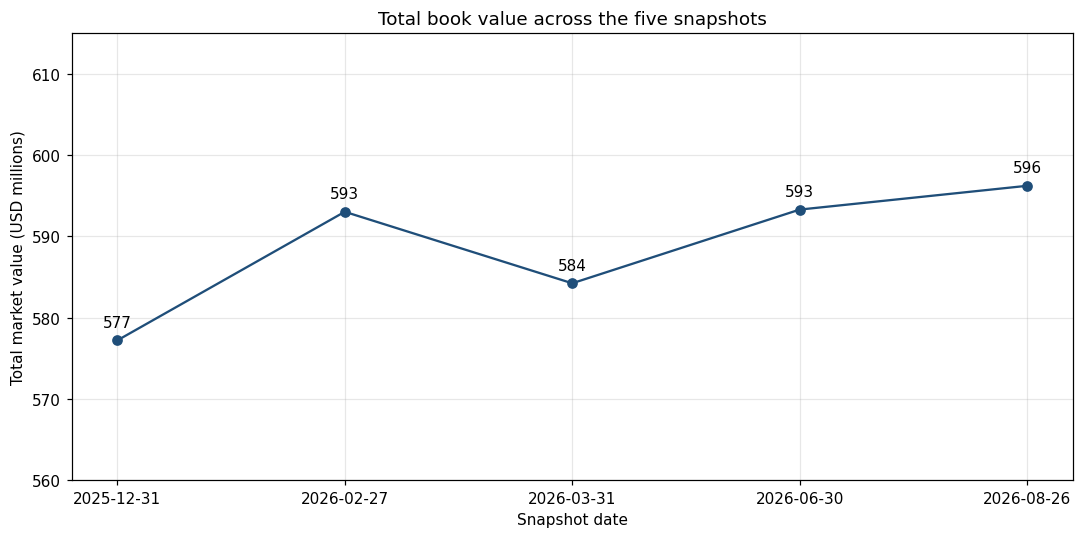

In [12]:
fig, ax = plt.subplots()
ax.plot(SNAPSHOTS, book.values / 1e6, marker="o", color="#1f4e79")
for x, y in zip(SNAPSHOTS, book.values / 1e6):
    ax.annotate(f"{y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 9), ha="center")
ax.set_title("Total book value across the five snapshots")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Total market value (USD millions)")
ax.set_ylim(560, 615)
plt.tight_layout()
plt.show()

,usd_m_start,usd_m_end,change_pct
asset_class,,,
Cash and Equivalents,50.5,49.0,-2.9
Fixed Income,150.8,139.0,-7.8
Equity,246.2,262.3,6.5
Alternatives,111.1,111.4,0.3
Commodities,15.4,17.5,13.5
Structured Products,3.2,17.0,432.4


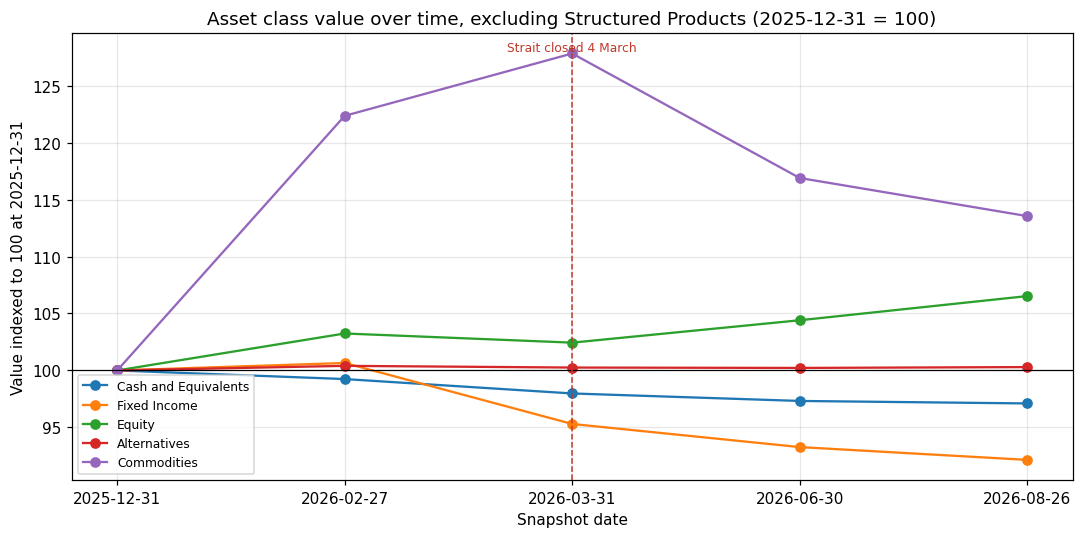

Structured Products is off this chart: its +432% is six new subscriptions, not a price move.


In [13]:
by_class = (
    holdings.pivot_table(
        index="snapshot_date", columns="asset_class", values="market_value_usd", aggfunc="sum"
    )
    .reindex(index=SNAPSHOTS, columns=ASSET_CLASSES)
)

summary = pd.DataFrame({
    "usd_m_start": (by_class.loc[FIRST] / 1e6).round(1),
    "usd_m_end": (by_class.loc[LAST] / 1e6).round(1),
    "change_pct": ((by_class.loc[LAST] / by_class.loc[FIRST] - 1) * 100).round(1),
})
display(summary)

# Structured Products is left off the chart: its +432% is six new subscriptions, not a price move,
# and plotting it flattens every other series into an unreadable band. Its numbers are in the
# table above, and section 11 explains why it grew.
priced_classes = [c for c in ASSET_CLASSES if c != "Structured Products"]
indexed = by_class / by_class.loc[FIRST] * 100

fig, ax = plt.subplots()
for column in priced_classes:
    ax.plot(SNAPSHOTS, indexed[column], marker="o", label=column)
ax.axhline(100, color="black", linewidth=0.8)
ax.axvline("2026-03-31", color="#c0392b", linestyle="--", linewidth=1)
ax.annotate(
    "Strait closed 4 March",
    xy=("2026-03-31", 1.0),
    xycoords=("data", "axes fraction"),
    xytext=(0, -12),
    textcoords="offset points",
    fontsize=8,
    color="#c0392b",
    ha="center",
)
ax.set_title("Asset class value over time, excluding Structured Products (2025-12-31 = 100)")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Value indexed to 100 at 2025-12-31")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()
print("Structured Products is off this chart: its +432% is six new subscriptions, not a price move.")

In [14]:
# Split the book's change into price, FX and new-position effects.
def client_instrument_snapshot(date):
    frame = holdings[holdings["snapshot_date"] == date]
    grouped = frame.groupby(["client_id", "instrument_id"]).agg(
        qty=("quantity", "sum"),
        px=("price_local", "first"),
        mv_usd=("market_value_usd", "sum"),
        mv_local=("market_value_local", "sum"),
    )
    grouped["usd_per_local"] = grouped["mv_usd"] / grouped["mv_local"]
    return grouped


start, end = client_instrument_snapshot(FIRST), client_instrument_snapshot(LAST)
joined = start.join(end, lsuffix="_s", rsuffix="_e", how="outer")
joined["usd_per_local_s"] = joined["usd_per_local_s"].fillna(joined["usd_per_local_e"])
joined["usd_per_local_e"] = joined["usd_per_local_e"].fillna(joined["usd_per_local_s"])
joined["px_s"] = joined["px_s"].fillna(joined["px_e"])
joined["px_e"] = joined["px_e"].fillna(joined["px_s"])
joined[["qty_s", "qty_e", "mv_usd_s", "mv_usd_e"]] = joined[
    ["qty_s", "qty_e", "mv_usd_s", "mv_usd_e"]
].fillna(0)

joined["price_effect"] = joined["qty_s"] * (joined["px_e"] - joined["px_s"]) * joined["usd_per_local_s"]
joined["fx_effect"] = joined["qty_s"] * joined["px_e"] * (joined["usd_per_local_e"] - joined["usd_per_local_s"])
joined["new_position_effect"] = (joined["qty_e"] - joined["qty_s"]) * joined["px_e"] * joined["usd_per_local_e"]
joined["total"] = joined["mv_usd_e"] - joined["mv_usd_s"]

effects = joined[["price_effect", "fx_effect", "new_position_effect", "total"]].sum()
contribution = effects / book.loc[FIRST] * 100

print("Book change 2025-12-31 -> 2026-08-26")
print(
    pd.DataFrame({
        "usd_m": (effects / 1e6).round(2),
        "contribution_pp": contribution.round(2),
    }).to_string()
)
print(f"\nunexplained residual: {(effects[:3].sum() - effects['total']):.2f} USD")
print(
    f"\nExcluding the unfunded new positions, the book returned "
    f"{contribution['price_effect'] + contribution['fx_effect']:+.2f}% in USD "
    f"({contribution['price_effect']:+.2f} from prices, {contribution['fx_effect']:+.2f} from the dollar)."
)
DECOMPOSITION = joined  # reused in section 4

Book change 2025-12-31 -> 2026-08-26
                     usd_m  contribution_pp
price_effect         12.62             2.19
fx_effect            -8.26            -1.43
new_position_effect  14.66             2.54
total                19.02             3.30

unexplained residual: 0.00 USD

Excluding the unfunded new positions, the book returned +0.76% in USD (+2.19 from prices, -1.43 from the dollar).


In [15]:
# The authoritative 2026 event record. Everything we say about causes must trace back to a row here.
events[["event_date", "event_type", "region", "severity", "primary_transmission"]]

,event_date,event_type,region,severity,primary_transmission
0,2025-12-31,Market,Global,High,"Gold, precious metals miners, inflation hedges"
1,2026-01-26,Market,Global,High,"Gold, precious metals"
2,2026-01-28,Market,Global,High,"Gold, precious metals"
3,2026-02-28,Geopolitical,Middle East,Severe,"Energy, defence, airlines, EM credit, safe havens"
4,2026-03-02,Market,Global,High,"Energy, transport, shipping"
5,2026-03-04,Geopolitical,Middle East,Severe,"Energy, LNG, shipping, Gulf credit, airlines"
6,2026-03-11,Policy,Global,High,"Energy, oil-linked structured products"
7,2026-03-12,Market,Global,Severe,"Energy, inflation-sensitive assets"
8,2026-04-30,Policy,Europe,Medium,"European fixed income, EUR assets"
9,2026-05-04,Market,Global,High,"Energy, transport"


In [16]:
# The market backdrop at the same five dates, so moves can be tied to levels.
key_series = ["BRENT_USD_BBL", "GOLD_USD_OZ", "UST_10Y_PCT", "VIX", "SPX", "US_CPI_YOY_PCT"]
market[market["series_id"].isin(key_series)].pivot_table(
    index="series_id", columns="snapshot_date", values="value"
).reindex(index=key_series, columns=SNAPSHOTS)

snapshot_date,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
series_id,,,,,
BRENT_USD_BBL,69.00,72.40,104.00,96.00,101.50
GOLD_USD_OZ,4310.00,5050.00,5240.00,4780.00,4622.60
UST_10Y_PCT,4.05,3.95,4.35,4.52,4.66
VIX,15.20,17.80,31.40,22.60,25.10
SPX,6902.00,7180.00,7050.00,7410.00,7530.00
US_CPI_YOY_PCT,2.70,2.90,3.40,4.20,4.00


In [17]:
# Which instruments actually moved, and in which direction.
prices = instruments.set_index("instrument_id")[[f"price_{d}" for d in SNAPSHOTS]]
moves = pd.DataFrame({
    "instrument_name": instruments.set_index("instrument_id")["instrument_name"],
    "sector": instruments.set_index("instrument_id")["sector"],
    "to_31_mar_pct": (prices[f"price_{SNAPSHOTS[2]}"] / prices[f"price_{FIRST}"] - 1) * 100,
    "full_period_pct": (prices[f"price_{LAST}"] / prices[f"price_{FIRST}"] - 1) * 100,
}).round(1)

print("BIGGEST FALLERS")
display(moves.sort_values("full_period_pct").head(7))
print("BIGGEST RISERS")
display(moves.sort_values("full_period_pct").tail(7).iloc[::-1])

BIGGEST FALLERS


,instrument_name,sector,to_31_mar_pct,full_period_pct
instrument_id,,,,
SYN-SP-0503,"Accumulator ref. Golden Harbour Properties Ltd, 12M",Real Estate,-23.6,-41.7
SYN-FI-0207,Golden Harbour Properties 5.25% Perpetual,Real Estate,-16.4,-31.1
SYN-ST-0106,Golden Harbour Properties Ltd,Real Estate,-14.5,-24.2
SYN-FI-0201,US Treasury 2.375% due 2045,Sovereign,-8.2,-14.9
SYN-FI-0206,Pacific Rim Bank 4.75% Perpetual,Financials,-7.6,-12.6
SYN-EQ-0010,Global Luxury and Consumer Brands Fund,Consumer Discretionary,-5.8,-9.1
SYN-FI-0205,Asia High Yield Bond Fund,Corporate,-5.9,-8.4


BIGGEST RISERS


,instrument_name,sector,to_31_mar_pct,full_period_pct
instrument_id,,,,
SYN-ST-0101,Bara Nusantara Energy Tbk,Energy,35.9,34.2
SYN-EQ-0007,Global Defence and Aerospace Equity Fund,Industrials,24.0,34.0
SYN-ST-0104,Pacific Orient Shipping Ltd,Industrials,26.6,28.6
SYN-EQ-0008,Global Energy Majors Equity Fund,Energy,28.0,26.5
SYN-EQ-0025,Asia Pacific Shipping and Logistics Fund,Industrials,19.0,20.1
SYN-CM-0403,Broad Commodity Index Fund,Diversified,20.6,19.3
SYN-ST-0103,Helios Cloud Systems Inc,Information Technology,5.2,18.5


## 4. Per-client allocation and drift

**What we check.** Asset-class allocation for each **household** (all of a client's portfolios added
together) at every snapshot, and how much each allocation moved between the first and last snapshot.
We also measure each client's return in their **own base currency**, not USD.

**Why it matters.** A bank owes its suitability assessment on the whole relationship, not on each
account separately, so a client's real risk is the sum of their portfolios. Reporting currency
matters just as much: a European client who earns, spends and pays tax in euros has not lost money
because the dollar rose, and telling them otherwise damages trust for no reason. Drift also carries
a governance meaning. Allocation that moved because markets moved is the bank's problem to correct;
allocation that moved because the client instructed a trade is the client's decision, and the two
belong in different queues with different paperwork.

**What we found.** Two findings, and the second is the one to build on.

**Currency of measurement changes the answer, and by a lot.** Andreas Lindqvist (CL-0009) is
**−4.0% in USD but +2.0% in EUR**. Margarethe Voss-Brenner is **−5.7% in USD but +0.2% in EUR** —
the difference between "you lost money" and "you broke even". Tan Boon Huat is −6.7% in USD but
−2.3% in SGD. The US dollar rose against every currency in the book (EURUSD 1.160 → 1.092, USDSGD
1.290 → 1.352, USDJPY 152 → 159), costing the USD-reported book **USD 8.3m that no client actually
lost**. Every non-USD client shows a gap of 4.5 to 6.0 percentage points. **The pipeline must report
client performance in the client's own base currency.**

**Risk profile and outcome are inverted this year.** Measured in base currency, the two worst
performers in the book are the **two Income clients** — Cheung Kwok Wing −7.0% and Chalermchai
Suphanburi −6.6% — followed by Lau Chi Ming −5.8% (HKD), Tan Boon Huat −2.3% (SGD) and Nguyen Thi
Bao Tran −1.6% (SGD). Neither Conservative client made money: Tan Boon Huat −2.3%, Margarethe
Voss-Brenner +0.2%. The four best are the aggressive ones: Abdullah Al-Mansoori +25.9%, Kim Do-Yoon
+25.3%, Hartono Wijaya Kusuma +23.4% (SGD) and Zhang Meiling +18.6%. **The clients who were told
bonds are the safe part are the clients who lost money**, which is exactly the conversation
Priscilla has to have (RM notes N-007, N-016, N-028).

The largest allocation drifts are all the new structured-product notes appearing from nothing:
Abdullah Al-Mansoori 0 → 12.9%, Kim Do-Yoon 0 → 12.8%, Zhang Meiling 0 → 7.1%, Lau Chi Ming
0 → 7.1%. Every one has a matching `Structured Product Subscription` transaction whose narrative
says the client asked for it, so these are **client-directed**, not passive drift — a different
governance category even though the arithmetic is identical.

> **Pipeline action.** Compute allocation at **household level in the client's base currency**, and
> publish both `return_base_ccy_pct` and `return_usd_pct` in `curated_client_bundle` — never one
> without the other. Tag each drift row `client_directed` when a transaction for that instrument
> exists inside the period and `market_drift` otherwise. That flag decides whether the RM sees a
> rebalancing prompt or a suitability review prompt.

In [18]:
household = (
    holdings.groupby(["client_id", "snapshot_date", "asset_class"], as_index=False)["market_value_usd"]
    .sum()
)
household_total = (
    holdings.groupby(["client_id", "snapshot_date"], as_index=False)["market_value_usd"]
    .sum()
    .rename(columns={"market_value_usd": "household_total_usd"})
)
household = household.merge(household_total, on=["client_id", "snapshot_date"])
household["pct"] = household["market_value_usd"] / household["household_total_usd"] * 100

allocation = household.pivot_table(
    index=["client_id", "asset_class"], columns="snapshot_date", values="pct"
).reindex(columns=SNAPSHOTS).fillna(0.0)
allocation["drift_pp"] = allocation[LAST] - allocation[FIRST]
allocation = allocation.reset_index()
allocation.insert(1, "client_name", allocation["client_id"].map(NAME))

top_drift = allocation.reindex(allocation["drift_pp"].abs().sort_values(ascending=False).index).head(12)
top_drift[["client_id", "client_name", "asset_class", FIRST, LAST, "drift_pp"]].round(2)

snapshot_date,client_id,client_name,asset_class,2025-12-31,2026-08-26,drift_pp
86,CL-0019,Abdullah Al-Mansoori,Structured Products,0.00,12.90,12.90
68,CL-0015,Kim Do-Yoon,Structured Products,0.00,12.84,12.84
57,CL-0013,Zhang Meiling,Structured Products,0.00,7.09,7.09
62,CL-0014,Lau Chi Ming,Structured Products,0.00,7.05,7.05
61,CL-0014,Lau Chi Ming,Fixed Income,50.55,44.19,-6.36
66,CL-0015,Kim Do-Yoon,Equity,52.84,46.60,-6.24
85,CL-0019,Abdullah Al-Mansoori,Fixed Income,21.06,15.67,-5.38
84,CL-0019,Abdullah Al-Mansoori,Equity,63.02,57.97,-5.04
6,CL-0002,Ravi Chandrasekaran,Alternatives,72.88,68.35,-4.53
55,CL-0013,Zhang Meiling,Equity,80.13,75.73,-4.39


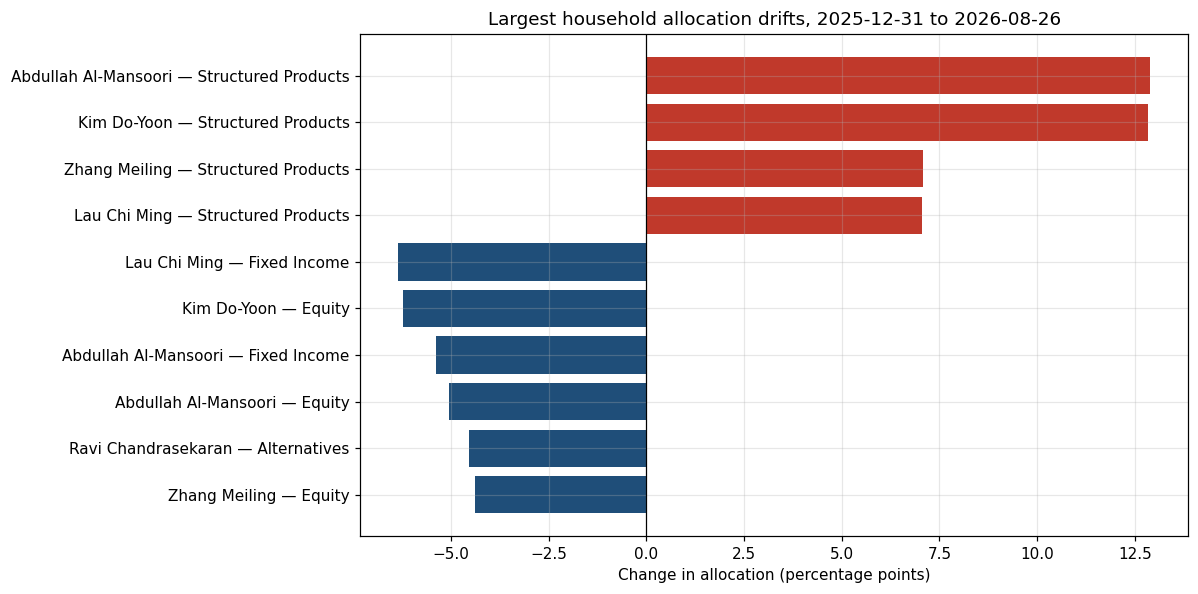

In [19]:
labels = [f"{r.client_name} — {r.asset_class}" for r in top_drift.head(10).itertuples()]
values = top_drift.head(10)["drift_pp"].to_numpy()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(labels[::-1], values[::-1], color=["#c0392b" if v > 0 else "#1f4e79" for v in values[::-1]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Largest household allocation drifts, 2025-12-31 to 2026-08-26")
ax.set_xlabel("Change in allocation (percentage points)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [20]:
# Return in USD versus return in the client's own base currency.
base_totals = (
    holdings.groupby(["client_id", "snapshot_date"])["market_value_base"].sum().unstack("snapshot_date")
).reindex(columns=SNAPSHOTS)
usd_totals = (
    holdings.groupby(["client_id", "snapshot_date"])["market_value_usd"].sum().unstack("snapshot_date")
).reindex(columns=SNAPSHOTS)

performance = pd.DataFrame({
    "client_name": pd.Series(NAME),
    "base_ccy": pd.Series(BASE_CCY),
    "risk_profile": clients.set_index("client_id")["risk_profile"],
    "usd_m_now": (usd_totals[LAST] / 1e6).round(1),
    "return_usd_pct": ((usd_totals[LAST] / usd_totals[FIRST] - 1) * 100).round(2),
    "return_base_ccy_pct": ((base_totals[LAST] / base_totals[FIRST] - 1) * 100).round(2),
})
performance["fx_gap_pp"] = (performance["return_usd_pct"] - performance["return_base_ccy_pct"]).round(2)
performance.sort_values("return_base_ccy_pct")

,client_name,base_ccy,risk_profile,usd_m_now,return_usd_pct,return_base_ccy_pct,fx_gap_pp
CL-0012,Cheung Kwok Wing,USD,Income,28.0,-6.98,-6.98,0.00
CL-0004,Chalermchai Suphanburi,USD,Income,33.5,-6.61,-6.61,0.00
CL-0014,Lau Chi Ming,HKD,Balanced,26.5,-6.01,-5.77,-0.24
CL-0011,Tan Boon Huat,SGD,Conservative,35.3,-6.73,-2.25,-4.48
CL-0006,Nguyen Thi Bao Tran,SGD,Balanced,18.1,-6.09,-1.58,-4.51
CL-0003,Margarethe Voss-Brenner,EUR,Conservative,22.2,-5.68,0.19,-5.87
CL-0009,Andreas Lindqvist,EUR,Balanced,31.6,-4.02,1.96,-5.98
CL-0018,Elena Marchetti-Wong,EUR,Balanced,22.6,-3.99,1.99,-5.98
CL-0017,Fong Enterprises Family Office,USD,Balanced,87.9,2.81,2.81,0.00
CL-0008,Chen Wei Ling,SGD,Balanced,12.0,-1.54,3.19,-4.73


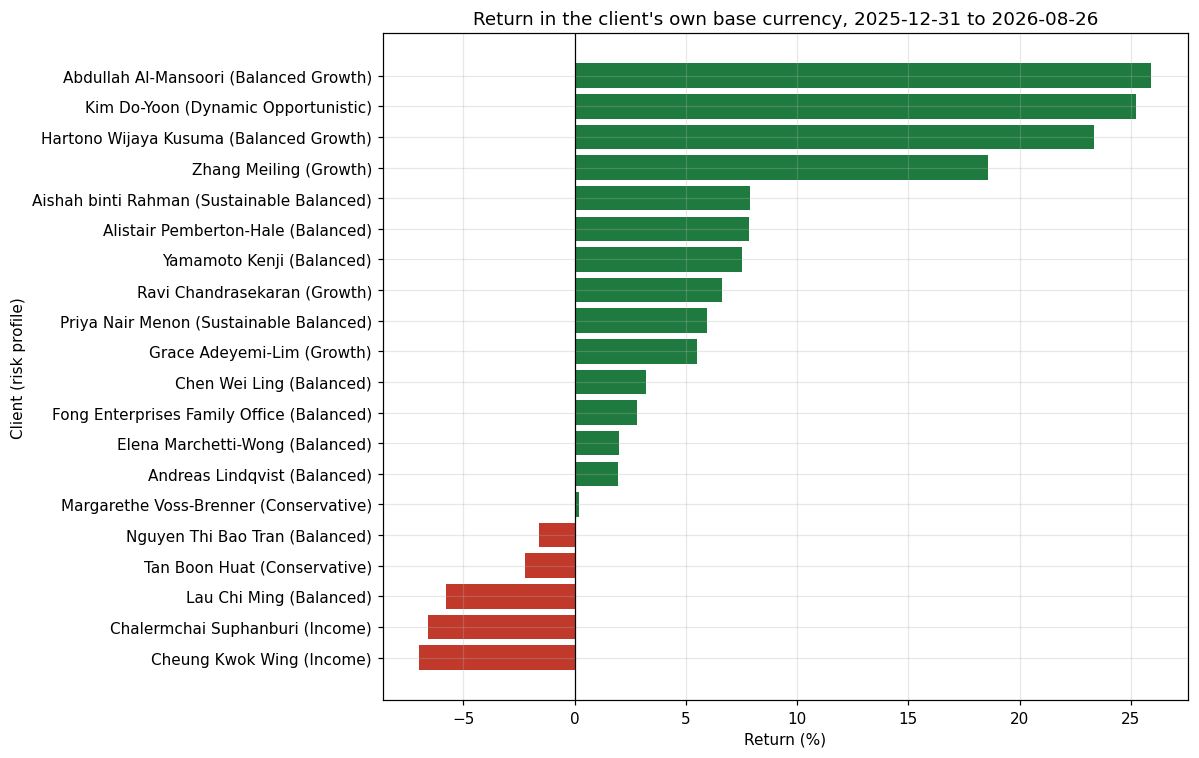

In [21]:
ordered = performance.sort_values("return_base_ccy_pct")
labels = [f"{n} ({p})" for n, p in zip(ordered["client_name"], ordered["risk_profile"])]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(labels, ordered["return_base_ccy_pct"],
        color=["#c0392b" if v < 0 else "#1f7a3f" for v in ordered["return_base_ccy_pct"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Return in the client's own base currency, 2025-12-31 to 2026-08-26")
ax.set_xlabel("Return (%)")
ax.set_ylabel("Client (risk profile)")
plt.tight_layout()
plt.show()

## 5. Mandate compliance

**What we check.** Every managed portfolio's allocation at the latest snapshot against the
`min_pct` / `max_pct` bands in `mandates.csv`, plus the single-position limit. Custody accounts are
excluded because the bank does not manage them and they are not measured against a mandate.

**Why it matters.** The mandate bands are the contract. Under the suitability regimes these
booking centres work to — MiFID II style rules in Europe, the FinSA/FINMA framework in Switzerland,
and the MAS conduct rules in Singapore — a bank that manages money against a stated risk profile
must be able to show the portfolio actually matches that profile, and must document any deviation.
A Conservative client sitting at 71% equity is not merely off-target; it is evidence that the
assessed risk profile and the risk actually being run have come apart. That is a compliance
exposure today and, if markets fall, a complaint the bank would struggle to defend. The operational
distinction is drift versus client-directed: drift is the bank's to correct, while a documented
instruction with a signed waiver on file is a different conversation entirely.

**What we found.** **14 band breaches across 9 of the 20 clients** at 2026-08-26. Ranked by gap:

| Client | Mandate | Asset class | Actual | Limit | Gap |
|---|---|---|---|---|---|
| Margarethe Voss-Brenner | Conservative | Equity | 71.46% | max 30% | **+41.5pp** |
| Margarethe Voss-Brenner | Conservative | Fixed Income | 9.15% | min 45% | −35.9pp |
| Tan Boon Huat | Conservative | Alternatives | 47.28% | max 15% | +32.3pp |
| Andreas Lindqvist | Balanced | Cash | 44.98% | max 18% | +27.0pp |
| Tan Boon Huat | Conservative | Fixed Income | 24.47% | min 45% | −20.5pp |
| Aishah binti Rahman | Sustainable Balanced | Equity | 67.74% | max 55% | +12.7pp |
| Yamamoto Kenji | Balanced | Equity | 67.72% | max 55% | +12.7pp |

**The golden number is confirmed exactly.** Margarethe Voss-Brenner (CL-0003) holds
**71.46% equity against a Conservative mandate that caps equity at 30%** — a 41.5 point breach, the
largest in the book — while her fixed income sits at 9.15% against a 45% floor. Her nine source
rows are printed below. Her risk tolerance score is 2 out of 10.

Three breaches have a stated cause in the RM notes and should be labelled differently from drift:
Alistair Pemberton-Hale's commodities overweight (18.93% vs 10% max) has a **signed suitability
waiver on file** (note N-010); Andreas Lindqvist's 45% cash is a client who agreed a deployment plan
twice and never executed it (N-013); Margarethe's breach is an **inherited portfolio the client
asked us not to change** (N-005).

Separately, the Sustainable Balanced mandate carries binding exclusions, and **Aishah binti Rahman
holds 21.3% of her sustainable mandate in instruments flagged `sustainability_excluded = Y`** —
Global Energy Majors (11.13%) and Sunrise Palm Resources (10.17%). Note N-008 records that she
believes the portfolio is fully aligned and was unaware of the energy fund. An exclusion breach is
stricter than a band breach: a band can be drifted through legitimately, whereas an exclusion is
binary and the mandate documentation says it is binding.

> **Pipeline action.** Two separate rules in stage S5. **`mandate_band_breach`** tests allocation
> against `min_pct`/`max_pct` per managed portfolio, filtering out `service_model == "Custody"`.
> **`mandate_exclusion_breach`** tests `sustainability_excluded == "Y"` against the mandate's
> exclusion list and is always severity `high`, never "drift". Every emitted breach carries the
> `mandates:<mandate_code>:<asset-class-slug>` evidence id plus the contributing
> `holdings:<snapshot>:<portfolio>:<instrument>` ids, and a `waiver_note_id` field populated from
> the RM notes when one exists — an alert that cannot see the waiver is a wrong alert.

In [22]:
latest = holdings[holdings["snapshot_date"] == TODAY]

portfolio_alloc = latest.groupby(["portfolio_id", "asset_class"], as_index=False)["market_value_base"].sum()
portfolio_total = (
    latest.groupby("portfolio_id", as_index=False)["market_value_base"].sum()
    .rename(columns={"market_value_base": "portfolio_total"})
)
portfolio_alloc = portfolio_alloc.merge(portfolio_total, on="portfolio_id")
portfolio_alloc["actual_pct"] = portfolio_alloc["market_value_base"] / portfolio_alloc["portfolio_total"] * 100

portfolio_alloc = (
    portfolio_alloc
    .merge(portfolios[["portfolio_id", "client_id", "mandate_code", "service_model"]], on="portfolio_id")
    .merge(mandates[["mandate_code", "asset_class", "min_pct", "target_pct", "max_pct"]],
           on=["mandate_code", "asset_class"], how="left")
)
portfolio_alloc["client_name"] = portfolio_alloc["client_id"].map(NAME)

managed = portfolio_alloc[portfolio_alloc["service_model"] != "Custody"].copy()
managed["over_max_pp"] = (managed["actual_pct"] - managed["max_pct"]).clip(lower=0)
managed["under_min_pp"] = (managed["actual_pct"] - managed["min_pct"]).clip(upper=0)
managed["gap_pp"] = managed["over_max_pp"] + managed["under_min_pp"]

breaches = managed[managed["gap_pp"] != 0].copy()
breaches["direction"] = np.where(breaches["gap_pp"] > 0, "above max", "below min")
breaches = breaches.reindex(breaches["gap_pp"].abs().sort_values(ascending=False).index)

print(f"band breaches at {TODAY}: {len(breaches)} across {breaches['client_id'].nunique()} clients")
print(f"custody portfolios excluded: {(portfolios['service_model'] == 'Custody').sum()}")
breaches[["client_id", "client_name", "portfolio_id", "mandate_code", "asset_class",
          "actual_pct", "min_pct", "max_pct", "gap_pp", "direction"]].round(2)

band breaches at 2026-08-26: 14 across 9 clients
custody portfolios excluded: 3


,client_id,client_name,portfolio_id,mandate_code,asset_class,actual_pct,min_pct,max_pct,gap_pp,direction
15,CL-0003,Margarethe Voss-Brenner,PF-0005,CONS,Equity,71.46,10,30,41.46,above max
16,CL-0003,Margarethe Voss-Brenner,PF-0005,CONS,Fixed Income,9.15,45,75,-35.85,below min
47,CL-0011,Tan Boon Huat,PF-0013,CONS,Alternatives,47.28,0,15,32.28,above max
40,CL-0009,Andreas Lindqvist,PF-0011,BAL,Cash and Equivalents,44.98,2,18,26.98,above max
50,CL-0011,Tan Boon Huat,PF-0013,CONS,Fixed Income,24.47,45,75,-20.53,below min
23,CL-0005,Aishah binti Rahman,PF-0007,SUSBAL,Equity,67.74,30,55,12.74,above max
73,CL-0016,Yamamoto Kenji,PF-0018,BAL,Equity,67.72,30,55,12.72,above max
42,CL-0009,Andreas Lindqvist,PF-0011,BAL,Fixed Income,14.45,25,50,-10.55,below min
31,CL-0007,Alistair Pemberton-Hale,PF-0009,BAL,Commodities,18.93,0,10,8.93,above max
62,CL-0014,Lau Chi Ming,PF-0016,BAL,Equity,23.39,30,55,-6.61,below min


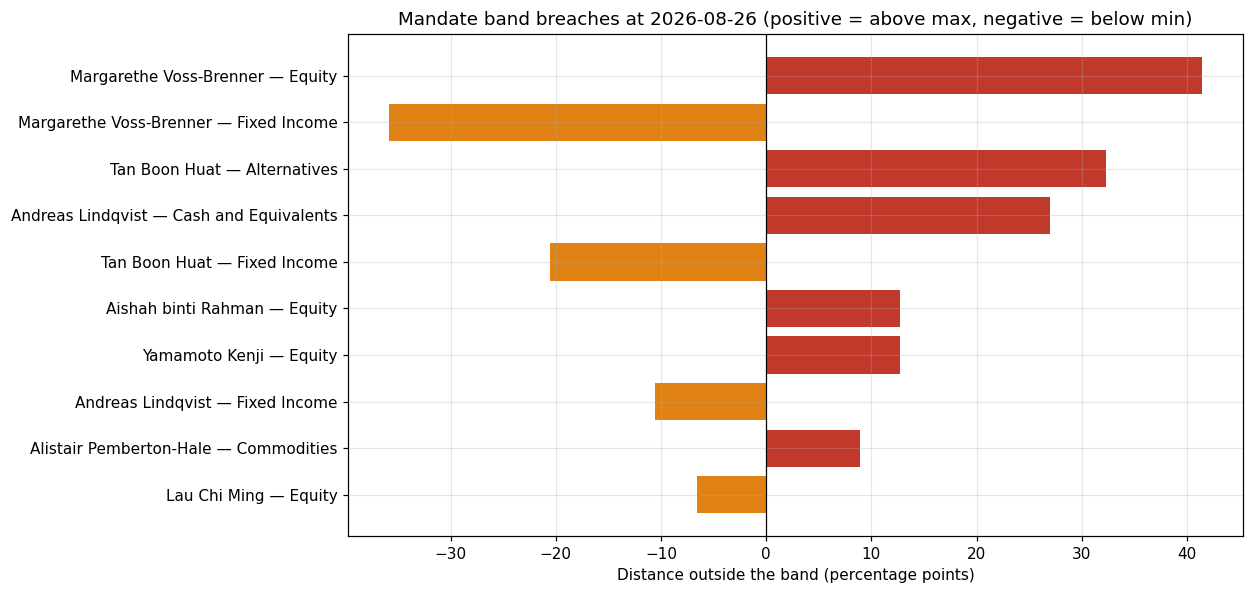

In [23]:
top_breaches = breaches.head(10).iloc[::-1]
labels = [f"{r.client_name} — {r.asset_class}" for r in top_breaches.itertuples()]

fig, ax = plt.subplots(figsize=(11.5, 5.5))
ax.barh(labels, top_breaches["gap_pp"],
        color=["#c0392b" if v > 0 else "#e08214" for v in top_breaches["gap_pp"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Mandate band breaches at {TODAY} (positive = above max, negative = below min)")
ax.set_xlabel("Distance outside the band (percentage points)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [24]:
# GOLDEN NUMBER 1 — Margarethe Voss-Brenner, CL-0003. Source rows, unaggregated.
mv = latest[latest["client_id"] == "CL-0003"]
display(
    mv[["portfolio_id", "instrument_id", "instrument_name", "asset_class", "instrument_ccy",
        "quantity", "price_local", "market_value_base", "weight_pct", "liquidity_tier"]]
    .sort_values("market_value_base", ascending=False)
)

total_eur = mv["market_value_base"].sum()
equity_eur = mv.loc[mv["asset_class"] == "Equity", "market_value_base"].sum()
cons_equity_max = mandates.loc[
    (mandates["mandate_code"] == "CONS") & (mandates["asset_class"] == "Equity"), "max_pct"
].item()

print(f"portfolio           : PF-0005, mandate CONS (Conservative), Advisory")
print(f"total (EUR)         : {total_eur:,.2f}")
print(f"equity (EUR)        : {equity_eur:,.2f}")
print(f"equity share        : {equity_eur / total_eur * 100:.2f}%")
print(f"mandate equity max  : {cons_equity_max:.0f}%")
print(f"breach              : {equity_eur / total_eur * 100 - cons_equity_max:.2f} percentage points")
print(f"client risk profile : {clients.set_index('client_id').loc['CL-0003', 'risk_profile']}"
      f" (tolerance {clients.set_index('client_id').loc['CL-0003', 'risk_tolerance_score']}/10)")

,portfolio_id,instrument_id,instrument_name,asset_class,instrument_ccy,quantity,price_local,market_value_base,weight_pct,liquidity_tier
130,PF-0005,SYN-EQ-0010,Global Luxury and Consumer Brands Fund,Equity,EUR,22000,240.6,5293200.00,26.0590,Daily
131,PF-0005,SYN-ST-0107,Nordvind Industrial AB,Equity,EUR,9000,414.7,3732300.00,18.3745,Daily
132,PF-0005,SYN-EQ-0004,European Equity Fund,Equity,EUR,18000,184.5,3321000.00,16.3496,Daily
133,PF-0005,SYN-EQ-0003,US Technology Leaders Fund,Equity,USD,4000,592.1,2168864.47,10.6775,Daily
135,PF-0005,SYN-FI-0209,EUR Investment Grade Bond Fund,Fixed Income,EUR,20000,92.9,1858000.00,9.1471,Daily
136,PF-0005,SYN-AL-0304,Harborline Long Short Equity Fund,Alternatives,USD,1100,1274.0,1283333.33,6.3180,Monthly
134,PF-0005,SYN-SP-0506,"Autocallable ref. Asia Banks Basket, 7.80% p.a.",Structured Products,USD,12000,99.6,1094505.49,5.3884,Illiquid
137,PF-0005,SYN-CA-0604,EUR Call Deposit,Cash and Equivalents,EUR,900000,1.0,900000.00,4.4308,Daily
138,PF-0005,SYN-CA-0605,CHF Call Deposit,Cash and Equivalents,CHF,600000,1.0,661192.00,3.2551,Daily


portfolio           : PF-0005, mandate CONS (Conservative), Advisory
total (EUR)         : 20,312,395.29
equity (EUR)        : 14,515,364.47
equity share        : 71.46%
mandate equity max  : 30%
breach              : 41.46 percentage points
client risk profile : Conservative (tolerance 2/10)


In [25]:
# Sustainable Balanced carries binding exclusions. Are they respected?
excl = (
    latest.merge(instruments[["instrument_id", "sustainability_excluded"]], on="instrument_id")
    .merge(portfolios[["portfolio_id", "mandate_code"]], on="portfolio_id")
)
susbal_breach = excl[(excl["mandate_code"] == "SUSBAL") & (excl["sustainability_excluded"] == "Y")]
susbal_breach = susbal_breach.assign(client_name=lambda d: d["client_id"].map(NAME))

print("Excluded instruments held inside a Sustainable Balanced mandate:")
display(
    susbal_breach[["client_id", "client_name", "portfolio_id", "instrument_name",
                   "market_value_base", "weight_pct"]].round(2)
)
print(f"total excluded weight in that mandate: {susbal_breach['weight_pct'].sum():.2f}%")

Excluded instruments held inside a Sustainable Balanced mandate:


,client_id,client_name,portfolio_id,instrument_name,market_value_base,weight_pct
44,CL-0005,Aishah binti Rahman,PF-0007,Global Energy Majors Equity Fund,2919103.2,11.13
45,CL-0005,Aishah binti Rahman,PF-0007,Sunrise Palm Resources Ltd,2667000.0,10.17


total excluded weight in that mandate: 21.30%


## 6. Look-through and concentration

**What we check.** Two kinds of risk that are invisible on a standard position report.

1. **Multi-portfolio aggregation.** A position that is 100% of a small custody account is only 41%
   of the household — but the reverse is what matters: a position that looks modest in one portfolio
   can dominate the household.
2. **Look-through.** `instruments.underlying_reference` says what a structured product is actually
   exposed to. Its `asset_class` only says what it is called. We also group instruments by
   **issuer**, so shares, a perpetual bond and an accumulator on the same company count as one bet.

**Method note.** All six structured products here are *worst-of* notes: the payoff is driven by
whichever named underlying performs worst. For risk purposes we therefore attribute the **full
notional to every named underlying**, and we say so — this is deliberately conservative and any
number we publish must carry that caveat.

**Why it matters.** Concentration limits exist because single-name risk is what actually destroys
private wealth — not volatility, but one position going to zero. Two things defeat a standard
position report. First, a structured product is booked as one line carrying the issuing bank's
name, but economically you own whatever sits in the basket; a worst-of note behaves much more like
selling insurance on every name in it than like holding a bond. Second, a client's shares, their
bonds and their derivatives on the same company are three lines on the statement and one bet in
reality — and if the issuer fails, all three fail together. Add household aggregation across
accounts and the true number can be double what any single report shows.

**What we found.** Four clients whose real single-issuer concentration only appears after this
treatment, and — more striking — **two clients who carry double-digit exposure to a company they do
not hold a single share of**.

| Client | Held directly | Via structured products | Look-through total | Single-position limit |
|---|---|---|---|---|
| Hartono Wijaya Kusuma (CL-0001) — Bara Nusantara Energy | 41.4% | 3.6% | **45.0%** | 15% |
| Lau Chi Ming (CL-0014) — Golden Harbour Properties | 22.4% (9.5% shares + 12.9% perpetual) | 7.1% accumulator | **29.5%** | 12% |
| Abdullah Al-Mansoori (CL-0019) — Pacific Orient Shipping | 11.4% | 12.9% | **24.3%** | 15% |
| Zhang Meiling (CL-0013) — Helios Cloud Systems | 15.4% | 7.1% | **22.5%** | 15% |
| **Abdullah Al-Mansoori — Bara Nusantara Energy** | **0.0%** | 12.9% | **12.9%** | 15% |
| **Kim Do-Yoon (CL-0015) — Helios Cloud Systems** | **0.0%** | 12.8% | **12.8%** | 20% |

**Lau Chi Ming is the strongest case in the book.** Three separate instruments — ordinary shares, a
perpetual bond and an accumulator — are one bet on one Hong Kong property company, and none of them
looks alarming on its own. Add the Mid-Levels apartment and Hong Kong property is **49% of his
household**. Every one of those instruments fell: accumulator −41.7%, perpetual −31.1%, shares
−24.2% — the three worst performers in the entire instrument universe. RM note N-018 records the RM
telling him "the perpetual, the shares, the accumulator and his own development business are all the
same bet" and the client answering "that is why he is confident".

**The zero-direct-holding cases are the ones a standard report can never surface.** Abdullah
Al-Mansoori's worst-of note names an Indonesian coal miner in its basket, so 12.9% of his wealth
moves with a stock that appears nowhere on his statement. Kim Do-Yoon is in the same position on a
US software company. There is no line item to click on.

Two more concentration facts worth carrying forward. Ravi Chandrasekaran (CL-0002) has **68.4% of
his household in one unlisted pre-IPO holding** that sits in a Custody account and is therefore
measured against no mandate at all — and that holding is also the stale valuation from section 11.
And Nordvind Industrial AB is held by two unrelated clients (CL-0003 at 18.4%, CL-0009 at 17.2%), so
one single-name shock hits two households at once.

> **Pipeline action.** Stage S3 builds two static reference maps that live in version control, not
> in code comments: `lookthrough_map` (structured product id → list of underlying instrument ids,
> derived by reading `instruments.underlying_reference`) and `issuer_map` (instrument id → issuer
> key, grouping shares, bonds and derivatives on one company). Stage S4 then computes
> `issuer_exposure_pct` at household level as direct holdings plus the **full notional** of every
> note referencing that issuer. Publish `direct_pct` and `lookthrough_pct` as separate fields with
> an explicit `attribution_basis: "worst_of_full_notional"` marker, so the conservative assumption
> travels with the number and any consumer can see it.

In [26]:
# Which structured products exist, what they really reference, and who holds them.
lookthrough_source = instruments.loc[
    instruments["underlying_reference"].notna(),
    ["instrument_id", "instrument_name", "asset_class", "liquidity_tier", "underlying_reference"],
]
lookthrough_source

,instrument_id,instrument_name,asset_class,liquidity_tier,underlying_reference
44,SYN-AL-0308,Unlisted Holding - Aranya Technologies Pte Ltd,Alternatives,Illiquid,"Series D preference shares, last priced round Sep-2025"
46,SYN-CM-0401,Physical Gold Allocated Account,Commodities,Daily,"XAU spot, allocated, Singapore vault"
47,SYN-CM-0402,Gold Bullion ETF,Commodities,Daily,XAU spot
49,SYN-SP-0501,"Fixed Coupon Note ref. Basket A, 8.50% p.a., 12M",Structured Products,Illiquid,Worst-of basket: Global Energy Majors ADR / Gulf Marine Services /...
50,SYN-SP-0502,"Equity Linked Note ref. Helios Cloud Systems, 11.00% p.a., 6M",Structured Products,Illiquid,Single underlying: Helios Cloud Systems Inc
51,SYN-SP-0503,"Accumulator ref. Golden Harbour Properties Ltd, 12M",Structured Products,Illiquid,"Daily accumulation at strike HKD 17.20, knock-out HKD 19.80, doubl..."
52,SYN-SP-0504,"Capital Protected Note ref. Gold, 24M",Structured Products,Illiquid,"Underlying: XAU spot, 100% capital protection at maturity, 70% par..."
53,SYN-SP-0505,"Fixed Coupon Note ref. Basket C, 9.20% p.a., 12M",Structured Products,Illiquid,Worst-of basket: Pacific Orient Shipping / Global Energy Majors AD...
54,SYN-SP-0506,"Autocallable ref. Asia Banks Basket, 7.80% p.a.",Structured Products,Illiquid,"Worst-of basket: three Asian banking majors, autocall observation ..."


In [27]:
# Read by hand from underlying_reference above. Worst-of => full notional to each named underlying.
LOOKTHROUGH = {
    "SYN-SP-0501": ["SYN-EQ-0008", "SYN-ST-0103"],   # energy majors + Helios (Gulf Marine not in universe)
    "SYN-SP-0502": ["SYN-ST-0103"],                   # Helios Cloud Systems, single underlying
    "SYN-SP-0503": ["SYN-ST-0106"],                   # Golden Harbour Properties accumulator
    "SYN-SP-0504": ["SYN-CM-0401"],                   # gold spot
    "SYN-SP-0505": ["SYN-ST-0104", "SYN-EQ-0008", "SYN-ST-0101"],  # shipping + energy + coal
    "SYN-SP-0506": [],                                # three Asian banks, not in the instrument universe
}

# Same-issuer grouping: different instruments, one credit/equity story.
ISSUER = {
    "SYN-ST-0106": "Golden Harbour Properties",
    "SYN-FI-0207": "Golden Harbour Properties",
    "SYN-SP-0503": "Golden Harbour Properties",
    "SYN-ST-0103": "Helios Cloud Systems",
    "SYN-SP-0502": "Helios Cloud Systems",
    "SYN-ST-0101": "Bara Nusantara Energy",
    "SYN-ST-0104": "Pacific Orient Shipping",
}

household_totals = latest.groupby("client_id")["market_value_usd"].sum()


def exposure_pct(client_id, instrument_ids):
    frame = latest[(latest["client_id"] == client_id) & (latest["instrument_id"].isin(instrument_ids))]
    return frame["market_value_usd"].sum() / household_totals[client_id] * 100


rows = []
for client_id in sorted(latest["client_id"].unique()):
    for issuer in sorted(set(ISSUER.values())):
        # instruments issued by this company, split into cash instruments and notes on it
        members = [i for i, name in ISSUER.items() if name == issuer]
        cash_instruments = [i for i in members if i not in LOOKTHROUGH]
        own_notes = [i for i in members if i in LOOKTHROUGH]
        # notes issued by anyone else whose underlying basket names this issuer
        referencing = [
            note for note, underlyings in LOOKTHROUGH.items()
            if note not in members and any(ISSUER.get(u) == issuer for u in underlyings)
        ]
        direct_pct = exposure_pct(client_id, cash_instruments)
        note_pct = exposure_pct(client_id, own_notes + referencing)
        if direct_pct + note_pct > 0:
            rows.append({
                "client_id": client_id,
                "client_name": NAME[client_id],
                "issuer": issuer,
                "direct_pct": direct_pct,
                "via_structured_product_pct": note_pct,
                "lookthrough_pct": direct_pct + note_pct,
            })

lookthrough = pd.DataFrame(rows)
lookthrough["uplift_pp"] = lookthrough["lookthrough_pct"] - lookthrough["direct_pct"]
lookthrough.sort_values("lookthrough_pct", ascending=False).round(2)

,client_id,client_name,issuer,direct_pct,via_structured_product_pct,lookthrough_pct,uplift_pp
0,CL-0001,Hartono Wijaya Kusuma,Bara Nusantara Energy,41.42,3.57,44.99,3.57
6,CL-0014,Lau Chi Ming,Golden Harbour Properties,22.41,7.05,29.45,7.05
9,CL-0019,Abdullah Al-Mansoori,Pacific Orient Shipping,11.41,12.90,24.31,12.90
5,CL-0013,Zhang Meiling,Helios Cloud Systems,15.40,7.09,22.49,7.09
8,CL-0019,Abdullah Al-Mansoori,Bara Nusantara Energy,0.00,12.90,12.90,12.90
7,CL-0015,Kim Do-Yoon,Helios Cloud Systems,0.00,12.84,12.84,12.84
2,CL-0002,Ravi Chandrasekaran,Helios Cloud Systems,4.43,3.37,7.80,3.37
4,CL-0012,Cheung Kwok Wing,Pacific Orient Shipping,5.83,0.00,5.83,0.00
3,CL-0012,Cheung Kwok Wing,Golden Harbour Properties,5.07,0.00,5.07,0.00
1,CL-0001,Hartono Wijaya Kusuma,Pacific Orient Shipping,0.00,3.57,3.57,3.57


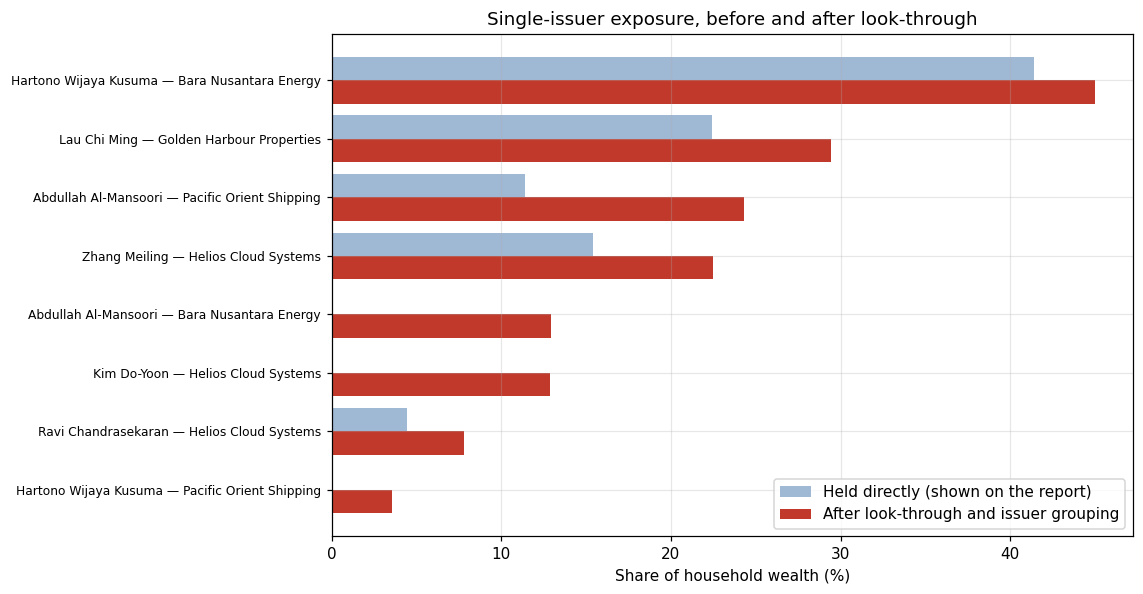

In [28]:
hidden = lookthrough[lookthrough["uplift_pp"] > 0].sort_values("lookthrough_pct")
labels = [f"{r.client_name} — {r.issuer}" for r in hidden.itertuples()]
y = np.arange(len(hidden))

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.barh(y + 0.2, hidden["direct_pct"], 0.4, label="Held directly (shown on the report)", color="#9fb8d4")
ax.barh(y - 0.2, hidden["lookthrough_pct"], 0.4, label="After look-through and issuer grouping", color="#c0392b")
ax.set_yticks(y, labels, fontsize=8)
ax.set_title("Single-issuer exposure, before and after look-through")
ax.set_xlabel("Share of household wealth (%)")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [29]:
# Single-position limits measured at household level, for instruments the limit is meant to apply to.
position_pct = (
    latest.merge(instruments[["instrument_id", "concentration_limit_applies"]], on="instrument_id")
    .groupby(["client_id", "instrument_id", "instrument_name", "concentration_limit_applies"], as_index=False)
    ["market_value_usd"].sum()
)
position_pct["household_pct"] = (
    position_pct["market_value_usd"] / position_pct["client_id"].map(household_totals) * 100
)
position_pct["client_name"] = position_pct["client_id"].map(NAME)

limits = (
    portfolios.merge(mandates[["mandate_code", "max_single_position_pct"]].drop_duplicates(), on="mandate_code")
    .groupby("client_id")["max_single_position_pct"].min()
)
position_pct["household_limit_pct"] = position_pct["client_id"].map(limits)

flagged = position_pct[
    (position_pct["concentration_limit_applies"] == "Y")
    & (position_pct["household_pct"] > position_pct["household_limit_pct"])
].sort_values("household_pct", ascending=False)

print("Single positions above the tightest single-position limit in the household:")
print("Caveat: the limit binds per managed portfolio. Measured at household level it is a risk")
print("signal, not a compliance finding — CL-0002's 68.4% sits in a Custody account.")
flagged[["client_id", "client_name", "instrument_name", "market_value_usd",
         "household_pct", "household_limit_pct"]].round(2)

Single positions above the tightest single-position limit in the household:
Caveat: the limit binds per managed portfolio. Measured at household level it is a risk
signal, not a compliance finding — CL-0002's 68.4% sits in a Custody account.


,client_id,client_name,instrument_name,market_value_usd,household_pct,household_limit_pct
11,CL-0002,Ravi Chandrasekaran,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.00,68.35,15.0
10,CL-0001,Hartono Wijaya Kusuma,Bara Nusantara Energy Tbk,19287976.54,41.42,15.0
97,CL-0011,Tan Boon Huat,Asia Real Estate Opportunity Fund III,7215976.33,20.42,10.0
153,CL-0016,Yamamoto Kenji,Kanto Pharma Holdings KK,2916729.56,20.10,12.0
127,CL-0014,Lau Chi Ming,Direct Property - Mid-Levels Apartment,5185659.41,19.58,12.0
28,CL-0003,Margarethe Voss-Brenner,Nordvind Industrial AB,4075671.60,18.37,10.0
98,CL-0011,Tan Boon Huat,Direct Property - Sentosa Cove Residence,6471893.49,18.32,10.0
131,CL-0014,Lau Chi Ming,Pacific Rim Bank 4.75% Perpetual,4653000.00,17.57,12.0
87,CL-0009,Andreas Lindqvist,Nordvind Industrial AB,5434228.80,17.19,12.0
126,CL-0013,Zhang Meiling,Helios Cloud Systems Inc,5691400.00,15.40,15.0


In [30]:
# The two clearest aggregation cases, shown from source rows.
for client_id in ["CL-0002", "CL-0014"]:
    frame = latest[latest["client_id"] == client_id].copy()
    frame["household_pct"] = frame["market_value_usd"] / frame["market_value_usd"].sum() * 100
    print(f"{client_id} — {NAME[client_id]}   household USD {frame['market_value_usd'].sum():,.0f}")
    display(
        frame[["portfolio_id", "instrument_name", "asset_class", "weight_pct", "household_pct"]]
        .sort_values("household_pct", ascending=False).round(2)
    )

CL-0002 — Ravi Chandrasekaran   household USD 46,699,200


,portfolio_id,instrument_name,asset_class,weight_pct,household_pct
93,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,Alternatives,100.00,68.35
81,PF-0003,US Technology Leaders Fund,Equity,24.04,7.61
82,PF-0003,Meridian Semiconductor Corp,Equity,15.18,4.80
83,PF-0003,Helios Cloud Systems Inc,Equity,14.00,4.43
84,PF-0003,India Equity Fund,Equity,11.46,3.63
87,PF-0003,"Equity Linked Note ref. Helios Cloud Systems, 11.00% p.a., 6M",Structured Products,10.64,3.37
85,PF-0003,Global Developed Equity Index Fund,Equity,9.66,3.06
86,PF-0003,Short Duration USD Bond Fund,Fixed Income,8.26,2.61
88,PF-0003,USD Call Deposit,Cash and Equivalents,6.77,2.14


CL-0014 — Lau Chi Ming   household USD 26,488,971


,portfolio_id,instrument_name,asset_class,weight_pct,household_pct
663,PF-0016,Direct Property - Mid-Levels Apartment,Alternatives,19.58,19.58
658,PF-0016,Pacific Rim Bank 4.75% Perpetual,Fixed Income,17.57,17.57
661,PF-0016,Greater China Equity Fund,Equity,13.84,13.84
662,PF-0016,Asia High Yield Bond Fund,Fixed Income,13.76,13.76
657,PF-0016,Golden Harbour Properties 5.25% Perpetual,Fixed Income,12.87,12.87
659,PF-0016,Golden Harbour Properties Ltd,Equity,9.54,9.54
660,PF-0016,"Accumulator ref. Golden Harbour Properties Ltd, 12M",Structured Products,7.05,7.05
664,PF-0016,HKD Call Deposit,Cash and Equivalents,5.80,5.80


## 7. Liquidity versus cash needs

**What we check.** For each client we compare what they have to pay in the next twelve months —
`planned_cash_needs.csv` plus uncalled private-market `commitments.csv` — against what they can
actually raise. We define three tiers from `holdings.liquidity_tier`:

- **Cash** — the `Cash and Equivalents` asset class.
- **Sellable in days** — anything with `liquidity_tier = Daily`.
- **Locked** — `Weekly`, `Monthly`, `Quarterly Gate` and `Illiquid`.

**Why it matters.** Liquidity in private banking is a tiering question, not a yes-or-no. Cash is
available today; listed funds and shares settle a couple of days after you sell; hedge funds
typically redeem monthly with notice; semi-liquid private credit vehicles deal quarterly and the
manager can pull a **gate** that limits how much of your redemption is actually met; private equity
cannot be sold at all and, worse, **calls** money from you on its own schedule. So a client can be
extremely wealthy and still unable to meet a dated bill. Forcing a sale into a bad market to hit a
tax deadline is precisely the outcome an advisory relationship exists to prevent — a dated
liability should be funded from assets deliberately matched to it, not from whatever happens to be
easiest to sell that week.

**What we found.** Across the book, USD 442.9m of the USD 596.2m is Daily; USD 87.9m is Illiquid and
USD 20.1m sits behind a quarterly gate. **No client is insolvent, but nine of the twenty cannot meet
their twelve-month obligations from cash and must sell something to pay.**

Ranked by cash cover (cash ÷ obligations): Alistair Pemberton-Hale 0.13x, Ravi Chandrasekaran 0.16x,
Fong Enterprises 0.17x, Nguyen Thi Bao Tran 0.19x, Grace Adeyemi-Lim 0.19x, Lau Chi Ming 0.20x,
Hartono Wijaya Kusuma 0.26x, Margarethe Voss-Brenner 0.46x, Abdullah Al-Mansoori 0.48x. Selling is
not itself a problem — but for three of them the assets are locked (Ravi Chandrasekaran has 72% of
his wealth in illiquid or gated holdings, Lau Chi Ming 57%, Tan Boon Huat 54%).

**Golden number 2 is confirmed.** Margarethe Voss-Brenner has a **confirmed EUR 3.4m German
inheritance-tax instalment due between 1 Oct and 31 Dec 2026** — inside four months. Her cash is
**EUR 1.56m, which covers 0.46x of it**. She has EUR 17.9m of Daily-liquid assets, so she can pay;
but funding it means selling, and what she would sell is the equity that is already 41 points
outside her mandate. **Her liquidity problem and her compliance problem have the same solution**,
which is the single most useful sentence in this notebook.

Two liquidity situations are worse in kind, not just degree:

- **Nguyen Thi Bao Tran (CL-0006)** needs USD 11.0m (US tuition plus PE capital calls). She
  submitted a full redemption on Orchard Private Credit Fund II in May; **the manager gated it and
  met roughly 22% of the request** (TXN-0008), and note N-023 records the fund has now gated three
  consecutive quarters. Her SGD assets fund USD obligations, and USDSGD moved from 1.290 to 1.352.
- **Lau Chi Ming (CL-0014)** owes an HKD 60m (USD 7.7m) redevelopment contribution by mid-2027
  against USD 1.5m of cash, and his Lombard facility is at 69.4% LTV against a 70% trigger — so
  selling collateral to raise the cash shrinks the lending value behind a facility that is already
  almost breached. Liquidity and collateral cannot be solved independently for this client.

> **Pipeline action.** Stage S3 maps `liquidity_tier` onto a settlement horizon in days
> (`Daily → 2`, `Weekly → 7`, `Monthly → 30`, `Quarterly Gate → 90` with a `gated: true` flag,
> `Illiquid → null`). Stage S4 computes `liquid_by_horizon` buckets and matches each
> `planned_cash_needs` row to the earliest bucket that settles before `due_from`, weighting by
> `certainty` (`Confirmed` = 1.0, `Likely` = 0.7, `Conditional`/`Aspirational` = 0.3 for the warn
> threshold, and 1.0 for the stress case). Uncalled `commitments` are treated as a liability that
> can be called at any time inside its `expected_call_window`, not as an asset. Gated positions
> must **never** count toward funding a dated need — CL-0006 is the proof.

In [31]:
LOCKED_TIERS = ["Weekly", "Monthly", "Quarterly Gate", "Illiquid"]
HORIZON_END = "2027-08-26"  # twelve months from today

print("Book-wide liquidity mix at " + TODAY + " (USD millions)")
display((latest.groupby("liquidity_tier")["market_value_usd"].sum() / 1e6).round(1).sort_values(ascending=False))

cash_now = latest[latest["asset_class"] == "Cash and Equivalents"].groupby("client_id")["market_value_usd"].sum()
daily_now = latest[latest["liquidity_tier"] == "Daily"].groupby("client_id")["market_value_usd"].sum()
locked_now = latest[latest["liquidity_tier"].isin(LOCKED_TIERS)].groupby("client_id")["market_value_usd"].sum()

needs = cash_needs.copy()
needs["amount_usd"] = [to_usd(a, c) for a, c in zip(needs["amount"], needs["currency"])]
needs_12m = needs.loc[needs["due_from"] <= HORIZON_END].groupby("client_id")["amount_usd"].sum()

calls = commitments.copy()
calls["uncalled_usd"] = [to_usd(a, c) for a, c in zip(calls["uncalled"], calls["currency"])]
uncalled = calls.groupby("client_id")["uncalled_usd"].sum()

liquidity = pd.DataFrame({
    "client_name": pd.Series(NAME),
    "total_usd": household_totals,
    "cash_usd": cash_now,
    "daily_usd": daily_now,
    "locked_usd": locked_now,
    "needs_12m_usd": needs_12m,
    "uncalled_usd": uncalled,
}).fillna(0.0)
liquidity["obligations_usd"] = liquidity["needs_12m_usd"] + liquidity["uncalled_usd"]
liquidity["cash_cover_x"] = (liquidity["cash_usd"] / liquidity["obligations_usd"].replace(0, np.nan)).round(2)
liquidity["daily_cover_x"] = (liquidity["daily_usd"] / liquidity["obligations_usd"].replace(0, np.nan)).round(2)
liquidity["locked_pct"] = (liquidity["locked_usd"] / liquidity["total_usd"] * 100).round(1)

money = ["total_usd", "cash_usd", "daily_usd", "needs_12m_usd", "uncalled_usd", "obligations_usd"]
liquidity_view = liquidity.sort_values("cash_cover_x")[
    ["client_name", *money, "cash_cover_x", "daily_cover_x", "locked_pct"]
].copy()
liquidity_view[money] = (liquidity_view[money] / 1e6).round(2)
liquidity_view = liquidity_view.rename(columns={c: c.replace("_usd", "_usd_m") for c in money})
liquidity_view

Book-wide liquidity mix at 2026-08-26 (USD millions)


liquidity_tier
Daily             442.9
Illiquid           87.9
Monthly            29.5
Quarterly Gate     20.1
Weekly             15.8
Name: market_value_usd, dtype: float64

,client_name,total_usd_m,cash_usd_m,daily_usd_m,needs_12m_usd_m,uncalled_usd_m,obligations_usd_m,cash_cover_x,daily_cover_x,locked_pct
CL-0007,Alistair Pemberton-Hale,40.02,1.60,35.18,12.00,0.0,12.00,0.13,2.93,12.1
CL-0002,Ravi Chandrasekaran,46.70,1.00,13.21,6.20,0.0,6.20,0.16,2.13,71.7
CL-0017,Fong Enterprises Family Office,87.90,5.39,54.62,16.70,15.8,32.50,0.17,1.68,37.9
CL-0020,Grace Adeyemi-Lim,19.06,0.85,17.85,3.60,0.9,4.50,0.19,3.97,6.3
CL-0006,Nguyen Thi Bao Tran,18.07,2.07,12.51,8.00,3.0,11.00,0.19,1.14,30.8
CL-0014,Lau Chi Ming,26.49,1.54,11.38,7.68,0.0,7.68,0.20,1.48,57.1
CL-0001,Hartono Wijaya Kusuma,46.57,1.73,41.64,6.66,0.0,6.66,0.26,6.26,10.6
CL-0003,Margarethe Voss-Brenner,22.18,1.70,19.58,3.71,0.0,3.71,0.46,5.27,11.7
CL-0019,Abdullah Al-Mansoori,32.21,2.40,26.12,5.00,0.0,5.00,0.48,5.22,18.9
CL-0011,Tan Boon Huat,35.34,2.37,16.26,2.07,0.0,2.07,1.14,7.85,54.0


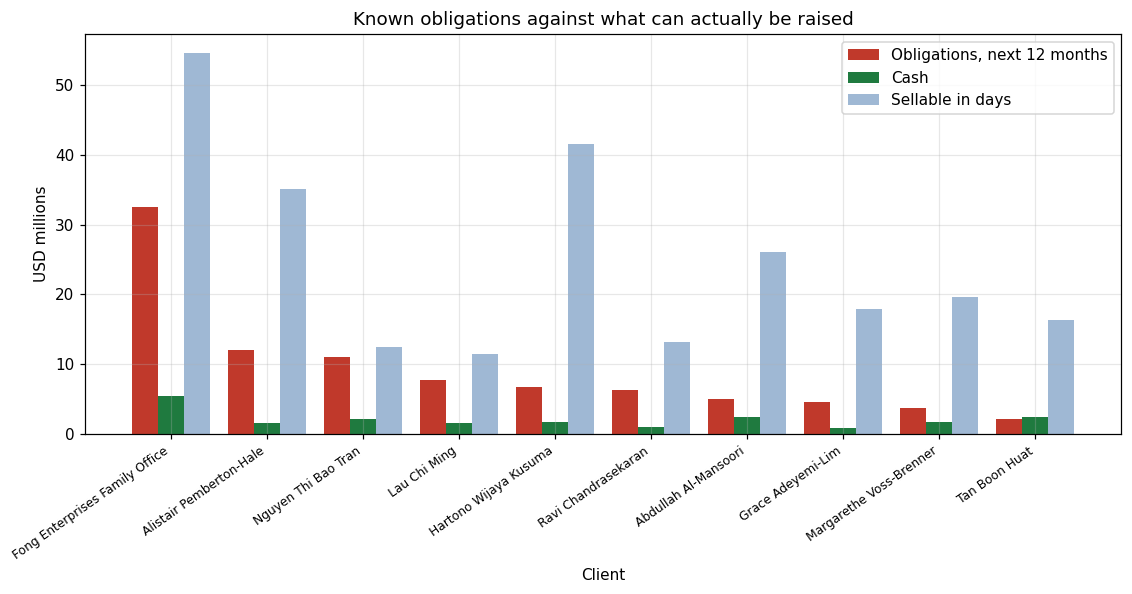

In [32]:
at_risk = liquidity[liquidity["obligations_usd"] > 0].sort_values("obligations_usd", ascending=False).head(10)
labels = list(at_risk["client_name"])
x = np.arange(len(at_risk))

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.bar(x - 0.27, at_risk["obligations_usd"] / 1e6, 0.27, label="Obligations, next 12 months", color="#c0392b")
ax.bar(x, at_risk["cash_usd"] / 1e6, 0.27, label="Cash", color="#1f7a3f")
ax.bar(x + 0.27, at_risk["daily_usd"] / 1e6, 0.27, label="Sellable in days", color="#9fb8d4")
ax.set_xticks(x, labels, rotation=35, ha="right", fontsize=8)
ax.set_title("Known obligations against what can actually be raised")
ax.set_xlabel("Client")
ax.set_ylabel("USD millions")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# GOLDEN NUMBER 2 — Margarethe Voss-Brenner's EUR 3.4m inheritance tax against her liquid assets.
need = cash_needs[cash_needs["client_id"] == "CL-0003"]
display(need)

mv_tiers = mv.groupby("liquidity_tier")["market_value_base"].sum()
mv_cash = mv.loc[mv["asset_class"] == "Cash and Equivalents", "market_value_base"].sum()
amount = float(need["amount"].iloc[0])

print(f"need                    : EUR {amount:,.0f}  due {need['due_from'].iloc[0]} to {need['due_to'].iloc[0]}"
      f"  ({need['certainty'].iloc[0]})")
print(f"cash on hand            : EUR {mv_cash:,.0f}   -> cover {mv_cash / amount:.2f}x")
print(f"sellable in days (Daily): EUR {mv_tiers.get('Daily', 0):,.0f}   -> cover {mv_tiers.get('Daily', 0) / amount:.2f}x")
print(f"locked                  : EUR {mv_tiers.drop('Daily', errors='ignore').sum():,.0f}")
print()
print("She can pay, but only by selling. The obvious thing to sell is the equity overweight,")
print("which is also the mandate breach in section 5.")

,need_id,client_id,description,currency,amount,due_from,due_to,recurrence,certainty
3,CN-004,CL-0003,German inheritance tax instalment,EUR,3400000,2026-10-01,2026-12-31,One-off,Confirmed


need                    : EUR 3,400,000  due 2026-10-01 to 2026-12-31  (Confirmed)
cash on hand            : EUR 1,561,192   -> cover 0.46x
sellable in days (Daily): EUR 17,934,556   -> cover 5.27x
locked                  : EUR 2,377,839

She can pay, but only by selling. The obvious thing to sell is the equity overweight,
which is also the mandate breach in section 5.


In [34]:
# The gated private credit fund, and who is sitting behind it.
gated = latest[latest["liquidity_tier"] == "Quarterly Gate"].assign(client_name=lambda d: d["client_id"].map(NAME))
display(gated[["client_id", "client_name", "portfolio_id", "instrument_name", "market_value_usd"]].round(0))

print("Redemption requests that were gated:")
display(
    transactions.loc[transactions["transaction_type"] == "Redemption Request",
                     ["transaction_id", "trade_date", "client_id", "instrument_name", "narrative"]]
)

,client_id,client_name,portfolio_id,instrument_name,market_value_usd
191,CL-0004,Chalermchai Suphanburi,PF-0006,Global Infrastructure Debt Fund,1803600.0
283,CL-0006,Nguyen Thi Bao Tran,PF-0008,Orchard Private Credit Fund II,1408400.0
472,CL-0010,Priya Nair Menon,PF-0012,Global Infrastructure Debt Fund,601200.0
517,CL-0011,Tan Boon Huat,PF-0013,Orchard Private Credit Fund II,3018000.0
576,CL-0012,Cheung Kwok Wing,PF-0014,Global Infrastructure Debt Fund,1202400.0
828,CL-0017,Fong Enterprises Family Office,PF-0020,Orchard Private Credit Fund II,9557000.0
831,CL-0017,Fong Enterprises Family Office,PF-0020,Global Infrastructure Debt Fund,2505000.0


Redemption requests that were gated:


,transaction_id,trade_date,client_id,instrument_name,narrative
197,TXN-0008,2026-05-12,CL-0006,Orchard Private Credit Fund II,Full redemption requested to fund USD capital calls. Manager appli...
201,TXN-0009,2026-06-24,CL-0011,Orchard Private Credit Fund II,Partial redemption of USD 1.5m requested. Manager applied the quar...


## 8. Credit and loan-to-value

**What we check.** The five credit facilities and their loan-to-value ratio at each of the five
snapshots, against each facility's own margin-call trigger. LTV here is `drawn ÷ lending_value`,
where lending value is market value after per-asset advance-rate haircuts — not raw market value.

**Why it matters.** Lombard lending is cash advanced against a pledged portfolio. The bank does not
lend against market value — it applies an **advance rate**, or haircut, to each position according
to how liquid and volatile it is, and the resulting **lending value** is the real collateral base.
A diversified bond fund might be advanced at 90%, a single stock at 50%, an illiquid private fund
at 0%. When drawn ÷ lending value crosses the margin-call trigger, the bank can demand more
collateral or sell the client's assets, usually within days. That makes distance-to-trigger the
only alert in this dataset with a hard clock on it. It is also doubly dangerous, because the same
market fall that cuts lending value is when the client least wants to be a forced seller.

**What we found.** Five facilities, USD-equivalent limits from SGD 6m to HKD 70m. **Two breached
their trigger during the period and both were cured by markets rather than by any action.**

| Facility | Client | Trigger | Dec-25 | Feb-26 | Mar-26 | Jun-26 | Aug-26 |
|---|---|---|---|---|---|---|---|
| CF-0005 | Hartono Wijaya Kusuma | 70% | **78.50%** | **75.68%** | 58.86% | 62.18% | 59.15% |
| CF-0001 | Ravi Chandrasekaran | 75% | 63.32% | 59.72% | 61.68% | **75.64%** | 73.71% |
| CF-0002 | Lau Chi Ming | 70% | 53.93% | 53.53% | 65.62% | 67.96% | **69.41%** |

- **CF-0005 was 8.5 points past its trigger at the 2025 year-end baseline.** It was cured on
  2026-03-31 by the Strait of Hormuz closure, which drove the collateral — a coal-mining
  shareholding — up 35.9%. The client did nothing. If the Strait reopens, this facility goes back
  into breach.
- **CF-0001 breached on 2026-06-30**, driven by the June technology drawdown compounded by the
  client drawing a further USD 1.7m on 2026-06-08 to fund a pre-IPO secondary (TXN-0012). Note
  N-004 records the RM warning him and the client proceeding anyway. It cured to 73.71% as tech
  recovered.
- **CF-0002 has never breached but is the one to watch: 69.41% against a 70.0% trigger — 0.59
  points of headroom, and rising every single snapshot.** Its collateral is Lau Chi Ming's Hong Kong
  property complex, which is still falling. This is the same client who owes HKD 60m by mid-2027.

The reason the trend matters more than the level: CF-0002's LTV has risen at every observation
(53.9 → 53.5 → 65.6 → 68.0 → 69.4) while CF-0003 and CF-0004 have been flat and comfortable
throughout. The signal should be direction plus distance, not distance alone — a facility drifting
toward its trigger over four consecutive readings is a conversation you can still have calmly,
whereas one that arrives at the trigger is a conversation about selling this week.

> **Pipeline action.** Stage S3 reshapes `credit_facilities` from its wide `<metric>_<date>` layout
> into long form keyed by `(facility_id, snapshot_date)` — this is the only table in the dataset
> that needs a wide-to-long transform, and doing it once at S3 keeps the date strings out of every
> downstream query. Stage S4 computes `ltv_headroom_pp` (trigger − current LTV) and
> `ltv_trend_direction` over the five snapshots. Lending value must be recomputed independently
> from `holdings.market_value_base × advance_rate_pct` so the published figure can be traced to
> positions rather than trusted from a summary column.

In [35]:
ltv = facilities.set_index("facility_id")[[f"ltv_pct_{d}" for d in SNAPSHOTS]]
ltv.columns = SNAPSHOTS

credit = facilities[["facility_id", "client_id", "collateral_portfolio_id", "facility_type",
                     "facility_ccy", "credit_limit", "margin_call_ltv_pct", "utilisation_pct_current"]].copy()
credit["client_name"] = credit["client_id"].map(NAME)
credit = credit.set_index("facility_id").join(ltv)
credit["headroom_pp_now"] = credit["margin_call_ltv_pct"] - credit[LAST]
credit["ltv_trend_pp"] = credit[LAST] - credit[FIRST]
credit["ever_breached"] = (ltv.gt(credit["margin_call_ltv_pct"], axis=0)).any(axis=1)

credit[["client_name", "facility_type", "facility_ccy", "credit_limit", "margin_call_ltv_pct",
        *SNAPSHOTS, "headroom_pp_now", "ltv_trend_pp", "ever_breached"]].round(2)

,client_name,facility_type,facility_ccy,credit_limit,margin_call_ltv_pct,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26,headroom_pp_now,ltv_trend_pp,ever_breached
facility_id,,,,,,,,,,,,,
CF-0001,Ravi Chandrasekaran,Lombard Credit Facility,USD,9000000,75.0,63.32,59.72,61.68,75.64,73.71,1.29,10.39,True
CF-0002,Lau Chi Ming,Lombard Credit Facility,HKD,70000000,70.0,53.93,53.53,65.62,67.96,69.41,0.59,15.48,False
CF-0003,Zhang Meiling,Lombard Credit Facility,USD,8000000,75.0,23.24,21.95,22.73,20.93,20.39,54.61,-2.85,False
CF-0004,Tan Boon Huat,Property Backed Term Loan,SGD,6000000,80.0,31.58,31.18,32.06,32.16,32.29,47.71,0.71,False
CF-0005,Hartono Wijaya Kusuma,Lombard Credit Facility,SGD,12000000,70.0,78.50,75.68,58.86,62.18,59.15,10.85,-19.35,True


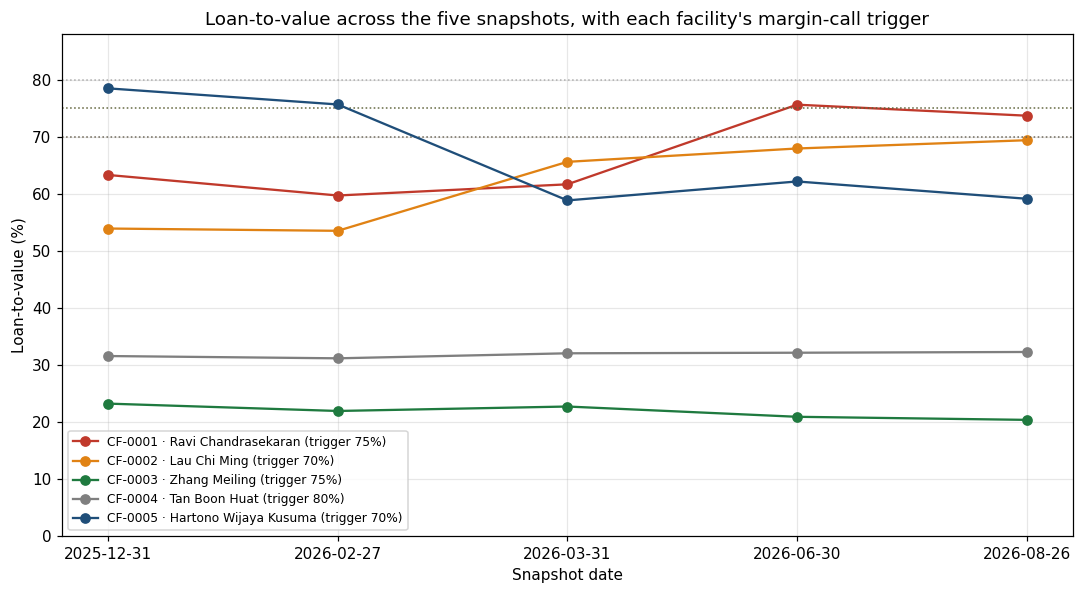

In [36]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#c0392b", "#e08214", "#1f7a3f", "#7f7f7f", "#1f4e79"]
for (facility_id, row), color in zip(ltv.iterrows(), colors):
    trigger = credit.loc[facility_id, "margin_call_ltv_pct"]
    label = f"{facility_id} · {credit.loc[facility_id, 'client_name']} (trigger {trigger:.0f}%)"
    ax.plot(SNAPSHOTS, row.to_numpy(), marker="o", color=color, label=label)
    ax.axhline(trigger, color=color, linestyle=":", linewidth=1, alpha=0.6)

ax.set_title("Loan-to-value across the five snapshots, with each facility's margin-call trigger")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Loan-to-value (%)")
ax.set_ylim(0, 88)  # leave clear space below the flat facilities for the legend
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

In [37]:
# Every snapshot where a facility sat above its own trigger.
breach_events = []
for facility_id, row in ltv.iterrows():
    trigger = credit.loc[facility_id, "margin_call_ltv_pct"]
    for date, value in row.items():
        if value > trigger:
            breach_events.append({
                "facility_id": facility_id,
                "client_name": credit.loc[facility_id, "client_name"],
                "snapshot_date": date,
                "ltv_pct": value,
                "trigger_pct": trigger,
                "over_by_pp": round(value - trigger, 2),
            })

display(pd.DataFrame(breach_events))
print("Facility drawdowns during the period, from transactions.csv:")
display(
    transactions.loc[transactions["transaction_type"] == "Facility Drawdown",
                     ["transaction_id", "trade_date", "client_id", "currency", "amount", "narrative"]]
)

,facility_id,client_name,snapshot_date,ltv_pct,trigger_pct,over_by_pp
0,CF-0001,Ravi Chandrasekaran,2026-06-30,75.64,75.0,0.64
1,CF-0005,Hartono Wijaya Kusuma,2025-12-31,78.50,70.0,8.50
2,CF-0005,Hartono Wijaya Kusuma,2026-02-27,75.68,70.0,5.68


Facility drawdowns during the period, from transactions.csv:


,transaction_id,trade_date,client_id,currency,amount,narrative
5,TXN-0013,2026-03-05,CL-0014,HKD,4000000.0,Additional drawdown to meet accumulator settlement obligations.
200,TXN-0012,2026-06-08,CL-0002,USD,1700000.0,Additional Lombard drawdown to fund a pre-IPO secondary purchase. ...


## 9. Currency and event exposure

**What we check.** Two things that travel together. First, how much of each client's wealth sits in
a currency other than the one they are reported in and will spend in. Second, which clients are
exposed to the transmission channels named in `event_log.csv` — with the Strait of Hormuz situation,
which the event log records as **unresolved as of today**, as the worked example.

**Why it matters.** Two exposures clients rarely ask about. **Currency**: a portfolio's job is to
fund a life that will be lived in a particular currency, so a Japanese client retiring to Japan
with 56% of his wealth outside the yen carries a real mismatch even if every holding performs
well. `tax_domicile` rather than `country_of_residence` drives what a disposal actually costs, and
in this book the two differ for most clients. **Events**: the point of a controlled event log is
that the bank can say "this holding moved because of this event" in a form a compliance reviewer
can audit, instead of a model free-associating about geopolitics in front of a client. The sharpest
case is when a client's portfolio and their business are the same bet — a concentration no account
statement can ever show, because half of it sits outside the bank.

**What we found.**

**Currency.** Hartono Wijaya Kusuma is reported in SGD and holds **97.1%** of his wealth in other
currencies, almost all of it one Indonesian rupiah stock; USDIDR moved 16,250 → 17,050 over the
period. Priya Nair Menon 72.1%, Aishah binti Rahman 61.3%, Yamamoto Kenji 56.4%. Yamamoto is the
sharpest case because it is not abstract: note N-021 says he **retires to Japan in 2030 and will
need yen income**, and 56% of his portfolio is not in yen.

**Strait of Hormuz exposure.** Mapping the event log's energy / shipping / Gulf transmission
channels onto holdings gives six exposed clients, and the top two are the ones where **portfolio
risk and source-of-wealth risk are the same risk**:

| Client | Energy + shipping exposure | Source of wealth |
|---|---|---|
| Hartono Wijaya Kusuma (CL-0001) | **45.0%** | Family coal mining and energy group |
| Abdullah Al-Mansoori (CL-0019) | **42.1%** | Gulf logistics, port services, marine chartering |
| Kim Do-Yoon (CL-0015) | 20.4% | Media production |
| Aishah binti Rahman (CL-0005) | 11.1% | Palm oil and property |
| Alistair Pemberton-Hale (CL-0007) | 6.5% | Retired commodities trader |
| Cheung Kwok Wing (CL-0012) | 5.8% | Retired shipping executive |

**Abdullah Al-Mansoori is the scenario client.** 42.1% of his portfolio is in the Strait trade —
a worst-of shipping and energy note (12.9%), Pacific Orient Shipping (11.4%), Global Energy Majors
(8.9%) and Asia Pacific Shipping and Logistics (8.9%). His operating business is Gulf port services
and marine chartering. He is up 25.9% this year and every point of it came from the same conflict.
Note N-025 records him saying "the point of the Asia portfolio was to be uncorrelated with the Gulf
business. It currently is not." Note N-026, dated two weeks ago, records him asking what happens if
the Strait reopens — and the RM's own answer in the file is **"We have not modelled this."** That is
the product gap, written down by the RM herself.

Hartono is the mirror image and the more dangerous position: 45% energy exposure, a coal-mining
family fortune, **and** a Lombard facility whose collateral is that same coal stock and which was in
breach before the energy rally cured it. A Strait reopening hits his portfolio, his family business
and his credit line simultaneously. He also told the RM this account was meant to be the wealth
*not* tied to the mine (N-001), which makes it a suitability conversation as well as a risk one.

> **Pipeline action.** Stage S3 builds a third reference map, `transmission_map`, joining
> `event_log.primary_transmission` channel keywords to instrument ids via `sector`, `region` and
> the look-through map — curated by hand and version-controlled, because keyword matching on free
> text is not defensible on its own. Stage S4 computes `channel_exposure_pct` per client per
> channel and a `wealth_correlation` flag when the channel also matches
> `clients.source_of_wealth`. Every event-driven claim published must cite its `event_log:` id;
> **if no event row supports a statement, the pipeline must not emit it.**

In [38]:
currency_mix = latest.groupby(["client_id", "instrument_ccy"], as_index=False)["market_value_usd"].sum()
currency_mix["pct"] = currency_mix["market_value_usd"] / currency_mix["client_id"].map(household_totals) * 100
currency_mix["base_ccy"] = currency_mix["client_id"].map(BASE_CCY)

in_base = (
    currency_mix[currency_mix["instrument_ccy"] == currency_mix["base_ccy"]]
    .groupby("client_id")["pct"].sum()
)
fx_risk = pd.DataFrame({
    "client_name": pd.Series(NAME),
    "base_ccy": pd.Series(BASE_CCY),
    "pct_in_base_ccy": in_base,
}).fillna(0.0)
fx_risk["pct_not_in_base_ccy"] = (100 - fx_risk["pct_in_base_ccy"]).round(1)
fx_risk = fx_risk.sort_values("pct_not_in_base_ccy", ascending=False)

print("FX moves over the period (market convention):")
display(FX.loc[[FIRST, LAST]].round(3))
fx_risk.round(1)

FX moves over the period (market convention):


series_id,EURUSD,GBPUSD,USDCHF,USDCNH,USDHKD,USDIDR,USDINR,USDJPY,USDSGD,USDTHB
snapshot_date,,,,,,,,,,
2025-12-31,1.160,1.345,0.790,7.08,7.79,16250.0,88.2,152.0,1.290,33.1
2026-08-26,1.092,1.282,0.831,7.23,7.81,17050.0,90.8,159.0,1.352,34.8


,client_name,base_ccy,pct_in_base_ccy,pct_not_in_base_ccy
CL-0001,Hartono Wijaya Kusuma,SGD,2.9,97.1
CL-0010,Priya Nair Menon,SGD,27.9,72.1
CL-0005,Aishah binti Rahman,SGD,38.7,61.3
CL-0016,Yamamoto Kenji,JPY,43.6,56.4
CL-0018,Elena Marchetti-Wong,EUR,53.2,46.8
CL-0014,Lau Chi Ming,HKD,55.8,44.2
CL-0008,Chen Wei Ling,SGD,56.2,43.8
CL-0009,Andreas Lindqvist,EUR,70.9,29.1
CL-0006,Nguyen Thi Bao Tran,SGD,73.2,26.8
CL-0003,Margarethe Voss-Brenner,EUR,74.4,25.6


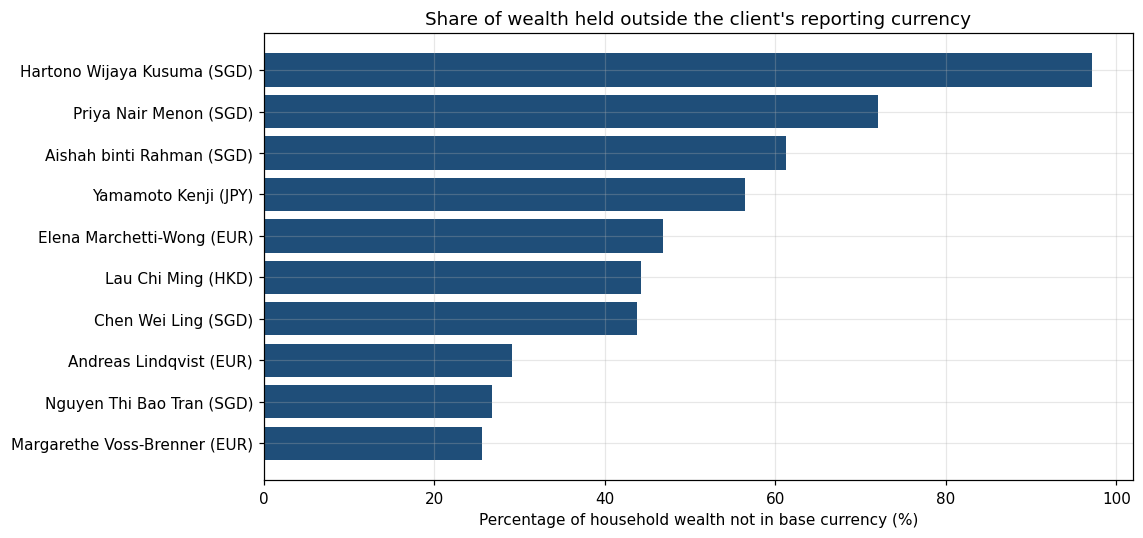

In [39]:
top_fx = fx_risk.head(10).iloc[::-1]
labels = [f"{n} ({c})" for n, c in zip(top_fx["client_name"], top_fx["base_ccy"])]

fig, ax = plt.subplots(figsize=(10.5, 5))
ax.barh(labels, top_fx["pct_not_in_base_ccy"], color="#1f4e79")
ax.set_title("Share of wealth held outside the client's reporting currency")
ax.set_xlabel("Percentage of household wealth not in base currency (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [40]:
# Map the event log's energy / shipping / Gulf channels onto actual instruments.
STRAIT_INSTRUMENTS = [
    "SYN-EQ-0008",  # Global Energy Majors Equity Fund
    "SYN-ST-0101",  # Bara Nusantara Energy (coal)
    "SYN-EQ-0025",  # Asia Pacific Shipping and Logistics
    "SYN-ST-0104",  # Pacific Orient Shipping
    "SYN-CM-0403",  # Broad Commodity Index
    "SYN-SP-0501",  # worst-of energy / tech note
    "SYN-SP-0505",  # worst-of shipping / energy note
    "SYN-EQ-0007",  # Defence and Aerospace
]

print("Events whose transmission channel names energy, shipping or the Gulf:")
display(
    events.loc[
        events["primary_transmission"].str.contains("Energy|shipping|Gulf|LNG|transport", case=False),
        ["event_date", "event_type", "description", "primary_transmission", "severity"],
    ]
)

strait = latest[latest["instrument_id"].isin(STRAIT_INSTRUMENTS)].groupby("client_id")["market_value_usd"].sum()
exposure = pd.DataFrame({
    "client_name": pd.Series(NAME),
    "source_of_wealth": clients.set_index("client_id")["source_of_wealth"],
    "strait_exposure_usd": strait,
    "household_usd": household_totals,
}).dropna(subset=["strait_exposure_usd"])
exposure["strait_pct"] = (exposure["strait_exposure_usd"] / exposure["household_usd"] * 100).round(1)
exposure["strait_exposure_usd_m"] = (exposure["strait_exposure_usd"] / 1e6).round(2)
exposure["household_usd_m"] = (exposure["household_usd"] / 1e6).round(2)
exposure.sort_values("strait_pct", ascending=False)[
    ["client_name", "source_of_wealth", "strait_exposure_usd_m", "household_usd_m", "strait_pct"]
]

Events whose transmission channel names energy, shipping or the Gulf:


,event_date,event_type,description,primary_transmission,severity
3,2026-02-28,Geopolitical,United States and Israel commence military operations against Iran.,"Energy, defence, airlines, EM credit, safe havens",Severe
4,2026-03-02,Market,Brent crude rises 10-13% to around USD 80-82 per barrel as tanker ...,"Energy, transport, shipping",High
5,2026-03-04,Geopolitical,Strait of Hormuz effectively closed. Brent surges past USD 120. Qa...,"Energy, LNG, shipping, Gulf credit, airlines",Severe
6,2026-03-11,Policy,IEA member countries agree to release 400 million barrels from eme...,"Energy, oil-linked structured products",High
7,2026-03-12,Market,IEA characterises the conflict as the largest supply disruption in...,"Energy, inflation-sensitive assets",Severe
9,2026-05-04,Market,Brent crude peaks at approximately USD 114 per barrel.,"Energy, transport",High
15,2026-08-05,Geopolitical,United States reimposes a naval blockade following renewed Iranian...,"Energy, shipping, insurance, Gulf exposure",Severe


,client_name,source_of_wealth,strait_exposure_usd_m,household_usd_m,strait_pct
CL-0001,Hartono Wijaya Kusuma,Inherited - family coal mining and energy group,20.95,46.57,45.0
CL-0019,Abdullah Al-Mansoori,"Entrepreneur - Gulf logistics, port services and marine chartering",13.57,32.21,42.1
CL-0015,Kim Do-Yoon,Entrepreneur - media production and artist management,3.05,14.99,20.4
CL-0005,Aishah binti Rahman,Entrepreneur - palm oil plantations and commercial property,2.16,19.40,11.1
CL-0007,Alistair Pemberton-Hale,Executive compensation - retired physical commodities trader,2.62,40.02,6.5
CL-0012,Cheung Kwok Wing,Executive compensation - retired shipping group executive,1.63,28.03,5.8


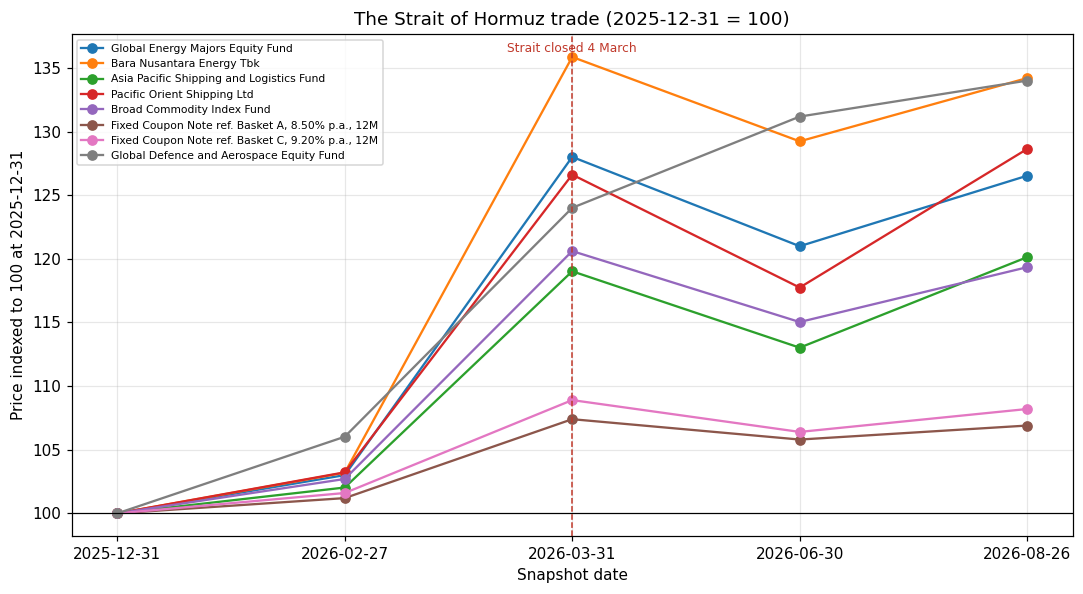

,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
instrument_name,,,,,
Global Energy Majors Equity Fund,100.0,103.0,128.0,121.0,126.5
Bara Nusantara Energy Tbk,100.0,103.2,135.9,129.2,134.2
Asia Pacific Shipping and Logistics Fund,100.0,102.0,119.0,113.0,120.1
Pacific Orient Shipping Ltd,100.0,103.2,126.6,117.7,128.6
Broad Commodity Index Fund,100.0,102.7,120.6,115.0,119.3
"Fixed Coupon Note ref. Basket A, 8.50% p.a., 12M",100.0,101.2,107.4,105.8,106.9
"Fixed Coupon Note ref. Basket C, 9.20% p.a., 12M",100.0,101.6,108.9,106.4,108.2
Global Defence and Aerospace Equity Fund,100.0,106.0,124.0,131.2,134.0


In [41]:
# How the Strait trade actually performed, snapshot by snapshot.
strait_prices = instruments.set_index("instrument_id").loc[
    STRAIT_INSTRUMENTS, [f"price_{d}" for d in SNAPSHOTS]
]
strait_prices.columns = SNAPSHOTS
strait_indexed = strait_prices.div(strait_prices[FIRST], axis=0) * 100
strait_indexed.index = instruments.set_index("instrument_id").loc[STRAIT_INSTRUMENTS, "instrument_name"]

fig, ax = plt.subplots(figsize=(10, 5.5))
for label, row in strait_indexed.iterrows():
    ax.plot(SNAPSHOTS, row.to_numpy(), marker="o", label=label)
ax.axhline(100, color="black", linewidth=0.8)
ax.axvline("2026-03-31", color="#c0392b", linestyle="--", linewidth=1)
ax.annotate(
    "Strait closed 4 March",
    xy=("2026-03-31", 1.0),
    xycoords=("data", "axes fraction"),
    xytext=(0, -12),
    textcoords="offset points",
    fontsize=8,
    color="#c0392b",
    ha="center",
)
ax.set_title("The Strait of Hormuz trade (2025-12-31 = 100)")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Price indexed to 100 at 2025-12-31")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

display(strait_indexed.round(1))

## 10. RM notes versus the data — "You said / Data says"

**What we check.** We read all 28 relationship-manager notes and, for the ones that contain a
client statement about their own portfolio, put that statement next to the number it is in tension
with.

**Why it matters.** This is where advice actually lives. A private bank's edge is not data, it is
knowing the client, and the most valuable thing in the file is usually the gap between what a
client believes about their money and what their money is doing. The notes also carry facts that
exist in no structured field anywhere: a signed suitability waiver, a dealing restriction on a
board member, a redemption gate that has not yet appeared in a valuation. A recommendation engine
that cannot read them will confidently propose things that are unsuitable, unexecutable, or already
agreed and on file. Presenting the gap as the client's own words beside the computed number is also
what makes it usable in a meeting rather than accusatory.

**What we found.** Nine notes contain a checkable client statement. All nine are contradicted or
sharpened by the data. Six of the strongest:

| Client | You said (RM note) | Data says (computed) |
|---|---|---|
| Margarethe Voss-Brenner | "never taken a risk with money"; wants "something safe and boring" (N-005, N-006) | 71.5% equity in a Conservative mandate capped at 30%; risk tolerance 2/10 |
| Hartono Wijaya Kusuma | The JB relationship is "the part of the family's wealth that is not tied to the mine" (N-001) | 41.4% of his household is one Indonesian coal stock; 45.0% is energy and shipping |
| Aishah binti Rahman | "believes the portfolio is fully aligned" with the family sustainability policy (N-008) | 21.3% of her sustainable mandate is in `sustainability_excluded = Y` instruments |
| Abdullah Al-Mansoori | "the point of the Asia portfolio was to be uncorrelated with the Gulf business" (N-025) | 42.1% is energy and shipping, the same trade as his port-services business |
| Cheung Kwok Wing | "he was told bonds were the safe part"; won't sell at a loss (N-016) | Fixed income cost him USD 2.48m; he is 71 and the longest bond matures in 2045 |
| Zhang Meiling | "dismissive of the suggestion that her exposure to a single name is high once the note is counted" (N-017) | Helios is 22.5% of her household once the note is counted, against a 15% limit |

Two notes contain information that appears **nowhere else in the structured data** and that the
pipeline would otherwise miss entirely:

- **N-010** records a **signed suitability waiver** for Alistair Pemberton-Hale's commodities
  overweight. Without it, his 18.93% versus 10% breach looks like negligence rather than a
  documented client instruction. Any breach alert that cannot see this note will be wrong.
- **N-021** records that Yamamoto Kenji is a **board member with dealing restrictions, and the next
  open window is November 2026**. Any recommendation to trade his employer shares before then is
  unexecutable.

There is also one note that is a to-do rather than an observation: **N-028, dated 19 August, one
week ago — Chalermchai Suphanburi asked whether he should move everything to deposits and Priscilla
has not yet replied.** He is the retiring client who needs USD 1.45m a year from Q2 2027 and whose
bonds are down 6.6%. Selling long bonds at a loss to sit in deposits would crystallise the loss and
give up the yield that is supposed to fund his retirement — a classic capitulation at the wrong
moment, and one an RM has a duty to talk through rather than execute. That is the single most
urgent unactioned item in the book.

> **Pipeline action.** Notes are a **first-class input, not decoration.** Stage S3 normalises
> `rm_notes.json` into one row per note with parsed dates. Stage S4 attaches to each client a
> `stated_beliefs` list (note id, quoted span, topic) and stage S5 pairs each belief with the
> computed fact that confirms or contradicts it, emitting a `belief_gap` signal carrying both the
> `rm_notes:<note_id>` evidence id and the contradicting fact id. Two derived flags must be
> extracted and honoured everywhere downstream: **`waiver_on_file`** (suppresses or reclassifies a
> breach alert) and **`dealing_restriction`** with its open window (suppresses any trade
> recommendation on that instrument until the window opens). Extraction is assisted but
> **RM-reviewed** — the notebook's table was built by reading all 28 notes by hand, and nothing in
> this dataset justifies trusting an unreviewed parse of free text.

In [42]:
notes.sort_values(["client_id", "note_date"]).assign(
    client_name=lambda d: d["client_id"].map(NAME)
)[["note_id", "client_id", "client_name", "note_date", "channel", "note"]]

,note_id,client_id,client_name,note_date,channel,note
0,N-001,CL-0001,Hartono Wijaya Kusuma,2026-01-08,Meeting,Annual review in Singapore. Client is more engaged than in prior y...
1,N-002,CL-0001,Hartono Wijaya Kusuma,2026-04-14,Call,Client called about the energy rally. Very positive on the outlook...
2,N-003,CL-0002,Ravi Chandrasekaran,2026-02-03,Meeting,"Secondary sale process is progressing, bankers indicate Q4 2026 at..."
3,N-004,CL-0002,Ravi Chandrasekaran,2026-06-11,Call,Difficult call. Client was agitated about the drop in his technolo...
4,N-005,CL-0003,Margarethe Voss-Brenner,2026-02-16,Meeting,First meeting following the transfer in. Mrs Voss-Brenner is still...
5,N-006,CL-0003,Margarethe Voss-Brenner,2026-05-29,Email,Client asked whether she should be worried about the news from the...
6,N-007,CL-0004,Chalermchai Suphanburi,2026-03-24,Meeting,Client is firm on retiring in Q2 2027 and handing the business to ...
27,N-028,CL-0004,Chalermchai Suphanburi,2026-08-19,Email,Client forwarded an article about interest rates and asked whether...
7,N-008,CL-0005,Aishah binti Rahman,2026-02-11,Meeting,Reviewed the sustainability policy the family adopted in 2024. Cli...
8,N-009,CL-0006,Nguyen Thi Bao Tran,2026-05-12,Call,Client needs USD liquidity for capital calls and the first US tuit...


In [43]:
# Build the "You said / Data says" table from computed facts, not from restated text.
def pct_asset(client_id, asset_class):
    frame = latest[latest["client_id"] == client_id]
    return frame.loc[frame["asset_class"] == asset_class, "market_value_usd"].sum() / frame["market_value_usd"].sum() * 100


def pct_instruments(client_id, instrument_ids):
    frame = latest[latest["client_id"] == client_id]
    return frame.loc[frame["instrument_id"].isin(instrument_ids), "market_value_usd"].sum() / frame["market_value_usd"].sum() * 100


fi_change = {}
for client_id in ["CL-0012", "CL-0004"]:
    start = holdings[(holdings["client_id"] == client_id) & (holdings["snapshot_date"] == FIRST)]
    end = holdings[(holdings["client_id"] == client_id) & (holdings["snapshot_date"] == LAST)]
    fi_change[client_id] = (
        end.loc[end["asset_class"] == "Fixed Income", "market_value_base"].sum()
        - start.loc[start["asset_class"] == "Fixed Income", "market_value_base"].sum()
    )

helios_lookthrough = lookthrough.loc[
    (lookthrough["client_id"] == "CL-0013") & (lookthrough["issuer"] == "Helios Cloud Systems"),
    "lookthrough_pct",
].item()

said_vs_data = pd.DataFrame([
    {
        "client": "CL-0003 Voss-Brenner", "note": "N-005 / N-006",
        "you_said": "\"never taken a risk with money\"; would prefer \"something safe and boring\"",
        "data_says": f"{pct_asset('CL-0003', 'Equity'):.1f}% equity in a Conservative mandate capped at 30%",
    },
    {
        "client": "CL-0001 Wijaya Kusuma", "note": "N-001",
        "you_said": "the JB relationship is the wealth \"not tied to the mine\"",
        "data_says": f"{pct_instruments('CL-0001', ['SYN-ST-0101']):.1f}% is one coal stock; "
                     f"{pct_instruments('CL-0001', STRAIT_INSTRUMENTS):.1f}% is energy and shipping",
    },
    {
        "client": "CL-0005 binti Rahman", "note": "N-008",
        "you_said": "believes the portfolio is fully aligned with the family sustainability policy",
        "data_says": f"{susbal_breach['weight_pct'].sum():.1f}% of the mandate is in excluded instruments",
    },
    {
        "client": "CL-0019 Al-Mansoori", "note": "N-025",
        "you_said": "the Asia portfolio was meant to be uncorrelated with the Gulf business",
        "data_says": f"{pct_instruments('CL-0019', STRAIT_INSTRUMENTS):.1f}% is the same energy and shipping trade",
    },
    {
        "client": "CL-0012 Cheung", "note": "N-016",
        "you_said": "was told bonds were the safe part; will not sell at a loss",
        "data_says": f"fixed income cost USD {abs(fi_change['CL-0012']):,.0f}; longest bond matures 2045, client is 71",
    },
    {
        "client": "CL-0013 Zhang", "note": "N-017",
        "you_said": "dismissive that single-name exposure is high once the note is counted",
        "data_says": f"Helios is {helios_lookthrough:.1f}% of the household after look-through, limit 15%",
    },
    {
        "client": "CL-0007 Pemberton-Hale", "note": "N-010",
        "you_said": "instructed more gold above the ceiling; suitability waiver on file",
        "data_says": f"commodities {pct_asset('CL-0007', 'Commodities'):.1f}% vs 10% max — breach is documented, not drift",
    },
    {
        "client": "CL-0016 Yamamoto", "note": "N-021",
        "you_said": "board dealing restrictions; next open window November 2026",
        "data_says": f"{fx_risk.loc['CL-0016', 'pct_not_in_base_ccy']:.1f}% not in JPY, retiring to Japan in 2030",
    },
    {
        "client": "CL-0004 Suphanburi", "note": "N-028 (19 Aug, unanswered)",
        "you_said": "asked whether he should move everything to deposits",
        "data_says": f"fixed income cost USD {abs(fi_change['CL-0004']):,.0f}; needs USD 1.45m a year from Q2 2027",
    },
])
said_vs_data

,client,note,you_said,data_says
0,CL-0003 Voss-Brenner,N-005 / N-006,"""never taken a risk with money""; would prefer ""something safe and ...",71.5% equity in a Conservative mandate capped at 30%
1,CL-0001 Wijaya Kusuma,N-001,"the JB relationship is the wealth ""not tied to the mine""",41.4% is one coal stock; 45.0% is energy and shipping
2,CL-0005 binti Rahman,N-008,believes the portfolio is fully aligned with the family sustainabi...,21.3% of the mandate is in excluded instruments
3,CL-0019 Al-Mansoori,N-025,the Asia portfolio was meant to be uncorrelated with the Gulf busi...,42.1% is the same energy and shipping trade
4,CL-0012 Cheung,N-016,was told bonds were the safe part; will not sell at a loss,"fixed income cost USD 2,482,300; longest bond matures 2045, client..."
5,CL-0013 Zhang,N-017,dismissive that single-name exposure is high once the note is counted,"Helios is 22.5% of the household after look-through, limit 15%"
6,CL-0007 Pemberton-Hale,N-010,instructed more gold above the ceiling; suitability waiver on file,"commodities 18.9% vs 10% max — breach is documented, not drift"
7,CL-0016 Yamamoto,N-021,board dealing restrictions; next open window November 2026,"56.4% not in JPY, retiring to Japan in 2030"
8,CL-0004 Suphanburi,"N-028 (19 Aug, unanswered)",asked whether he should move everything to deposits,"fixed income cost USD 2,204,500; needs USD 1.45m a year from Q2 2027"


## 11. Data imperfections catalogue

**What we check.** Everything in the data that is wrong, stale, missing, or structurally surprising
— found by the checks in sections 1 to 10 rather than assumed.

**Why it matters.** Every bank's data has seams. Portfolios transfer in without tax lot history,
private funds report a quarter late, unlisted holdings carry the last funding round's price until
the next one prices. Handling these well is not a data-cleaning nicety — it decides whether a
number can be shown to a client at all. A cost basis we invented would produce a tax figure someone
might act on. A concentration percentage built on an eleven-month-old valuation needs its age
printed next to it. The professional answer is to surface the uncertainty rather than smooth it
away, which is also what the challenge brief asks for.

**What we found.** Ten items. The two marked **high** materially change results if ignored.

The most consequential is not a broken value at all — it is a structural property. **`holdings.csv`
and `transactions.csv` do not reconcile.** Across all five snapshots exactly one position quantity
ever changes (Alistair Pemberton-Hale's gold ETF, 6,000 → 8,000 units) and six new positions appear
(the structured-product subscriptions). Nothing is ever sold, no cash balance ever moves, and the
148 dividends, 92 coupons, 48 management fees and 4 withdrawals in `transactions.csv` leave no trace
in `holdings.csv`. Two consequences: the pipeline must treat **holdings as the sole source of truth
for positions and transactions as an event and narrative source only**; and **book growth is
overstated by USD 14.7m** because those seven purchases were never funded from anything.

The second high-severity item is the **inherited portfolio PF-0005**. All nine positions carry
`acquired_date = 2026-02-16` — the date of the transfer-in — yet they appear in the 2025-12-31
snapshot, two months *before* they were acquired. TXN-0018 explains it: the portfolio came in from
another institution after the account holder's spouse died, and "tax lot history was not provided
for all positions". So the history is a backfill, and one position (Nordvind Industrial AB) has no
cost basis at all. **Any unrealised gain or tax-loss-harvesting calculation on this client will be
wrong**, which matters because she is the client with the largest mandate breach and a tax bill due
in four months. Her German domicile makes it worse: a disposal to fund the inheritance-tax
instalment has its own tax consequence, and we cannot compute it on the position we would most
likely sell.

> **Pipeline action.** The catalogue below is not documentation — it is the **specification for
> `data_quality_report.json`**, which stage S2 publishes on every run. Each row becomes an entry
> with `id`, `severity`, `scope` (the affected file, rows and client ids), `detection` (the exact
> check that finds it, so it is re-detected rather than hardcoded) and `handling`. Two of these
> rules must additionally set per-client suppression flags that travel in
> `curated_client_bundle`: `cost_basis_available: false` for CL-0003 (blocks all tax output) and
> `valuation_age_days` on every position (forces stale marks to be labelled wherever shown).

In [44]:
imperfections = pd.DataFrame([
    {
        "id": "DQ-01", "severity": "high",
        "where": "holdings.csv vs transactions.csv",
        "what": "Only 1 of 206 position quantities ever changes and 6 new positions appear; nothing is "
                "ever sold, no cash balance moves, and no dividend, coupon, fee or withdrawal is "
                "reflected. The two files do not reconcile.",
        "pipeline_should": "Treat holdings as the only source of truth for positions and valuations. "
                           "Use transactions for events, narratives and client intent only, never to "
                           "roll forward balances.",
    },
    {
        "id": "DQ-02", "severity": "high",
        "where": "holdings.csv — 6 structured products + 1 gold purchase",
        "what": "USD 14.7m of new positions appear with no offsetting sale or cash reduction, "
                "inflating book growth from roughly +2.2% to the headline +3.30%.",
        "pipeline_should": "Report performance from the price and FX effects only. Show subscriptions "
                           "as a separate 'new positions' line, never inside a return figure.",
    },
    {
        "id": "DQ-03", "severity": "high",
        "where": "holdings.csv — PF-0005 (CL-0003), all 9 rows",
        "what": "acquired_date = 2026-02-16 for every position, but the positions appear in the "
                "2025-12-31 and 2026-02-27 snapshots — acquired after the date they are reported at. "
                "TXN-0018 shows the portfolio was transferred in on that date and the history backfilled.",
        "pipeline_should": "Treat acquired_date on transferred-in portfolios as the transfer date, not "
                           "the purchase date. Suppress holding-period and tax-lot logic for CL-0003 and "
                           "say why.",
    },
    {
        "id": "DQ-04", "severity": "medium",
        "where": "holdings.csv — SYN-ST-0107 Nordvind Industrial AB, 5 rows",
        "what": "avg_cost_local, cost_basis_base, unrealised_pnl_base and unrealised_pnl_pct are all null. "
                "Cost basis was not supplied on transfer-in.",
        "pipeline_should": "Show unrealised P&L as 'not available' for this position. Never impute a cost "
                           "basis; an invented tax number is worse than a blank.",
    },
    {
        "id": "DQ-05", "severity": "medium",
        "where": "holdings.csv — SYN-AL-0308 Aranya Technologies, all 5 snapshots",
        "what": "valuation_date is 2025-09-30 at every snapshot, so the mark is 11 months stale at "
                "today, and it is 68.4% of CL-0002's household wealth. TXN-0019 confirms a June review "
                "left the carrying price unchanged.",
        "pipeline_should": "Surface valuation age wherever this position is shown. Exclude stale private "
                           "marks from performance attribution and flag concentration built on them.",
    },
    {
        "id": "DQ-06", "severity": "low",
        "where": "instruments.csv / holdings.csv — SYN-SP-0506",
        "what": "sector is null for the Asia Banks autocallable (5 holdings rows and 1 instrument row).",
        "pipeline_should": "Fall back to sub_asset_class and region for sector grouping; never drop the "
                           "row from a sector chart.",
    },
    {
        "id": "DQ-07", "severity": "low",
        "where": "clients.csv — CL-0017",
        "what": "age is null. Fong Enterprises Family Office is a legal entity, not a person.",
        "pipeline_should": "Guard every age-based rule (retirement horizon, life stage) against nulls "
                           "rather than defaulting to a number.",
    },
    {
        "id": "DQ-08", "severity": "medium",
        "where": "instruments.csv — private market marks",
        "what": "Private equity and private real estate prices repeat across consecutive snapshots "
                "(Meridian PE VII holds 1420.00 from Dec to Mar; the two direct properties hold one "
                "price for three snapshots). This is normal quarterly reporting lag, not an error.",
        "pipeline_should": "Exclude quarterly-marked assets from short-horizon attribution and label "
                           "them 'valued as at <date>' rather than implying a live price.",
    },
    {
        "id": "DQ-09", "severity": "medium",
        "where": "holdings.csv — advance_rate_pct on Illiquid structured products",
        "what": "Illiquid structured products carry advance rates from 0% to 60%, so 'Illiquid' does not "
                "imply zero collateral value. Lending value must come from advance_rate_pct, not from "
                "the liquidity tier.",
        "pipeline_should": "Compute lending value as market value x advance_rate_pct per position. Never "
                           "infer collateral value from liquidity_tier.",
    },
    {
        "id": "DQ-10", "severity": "medium",
        "where": "market_context.csv FX conventions",
        "what": "Pairs are quoted in market convention: USDSGD is SGD per USD, EURUSD is USD per EUR. "
                "Dividing when you should multiply gives a plausible-looking wrong answer.",
        "pipeline_should": "Use one tested conversion helper everywhere (see to_usd above) and unit-test "
                           "it against holdings.market_value_usd / market_value_local.",
    },
])
imperfections

,id,severity,where,what,pipeline_should
0,DQ-01,high,holdings.csv vs transactions.csv,Only 1 of 206 position quantities ever changes and 6 new positions...,Treat holdings as the only source of truth for positions and valua...
1,DQ-02,high,holdings.csv — 6 structured products + 1 gold purchase,USD 14.7m of new positions appear with no offsetting sale or cash ...,Report performance from the price and FX effects only. Show subscr...
2,DQ-03,high,"holdings.csv — PF-0005 (CL-0003), all 9 rows","acquired_date = 2026-02-16 for every position, but the positions a...",Treat acquired_date on transferred-in portfolios as the transfer d...
3,DQ-04,medium,"holdings.csv — SYN-ST-0107 Nordvind Industrial AB, 5 rows","avg_cost_local, cost_basis_base, unrealised_pnl_base and unrealise...",Show unrealised P&L as 'not available' for this position. Never im...
4,DQ-05,medium,"holdings.csv — SYN-AL-0308 Aranya Technologies, all 5 snapshots","valuation_date is 2025-09-30 at every snapshot, so the mark is 11 ...",Surface valuation age wherever this position is shown. Exclude sta...
5,DQ-06,low,instruments.csv / holdings.csv — SYN-SP-0506,sector is null for the Asia Banks autocallable (5 holdings rows an...,Fall back to sub_asset_class and region for sector grouping; never...
6,DQ-07,low,clients.csv — CL-0017,"age is null. Fong Enterprises Family Office is a legal entity, not...","Guard every age-based rule (retirement horizon, life stage) agains..."
7,DQ-08,medium,instruments.csv — private market marks,Private equity and private real estate prices repeat across consec...,Exclude quarterly-marked assets from short-horizon attribution and...
8,DQ-09,medium,holdings.csv — advance_rate_pct on Illiquid structured products,"Illiquid structured products carry advance rates from 0% to 60%, s...",Compute lending value as market value x advance_rate_pct per posit...
9,DQ-10,medium,market_context.csv FX conventions,"Pairs are quoted in market convention: USDSGD is SGD per USD, EURU...",Use one tested conversion helper everywhere (see to_usd above) and...


In [45]:
# Evidence for the two high-severity structural findings.
quantities = holdings.pivot_table(
    index=["portfolio_id", "instrument_id"], columns="snapshot_date", values="quantity", aggfunc="sum"
).reindex(columns=SNAPSHOTS)

changed = quantities[quantities.nunique(axis=1, dropna=True) > 1]
appeared = quantities[quantities[FIRST].isna() & quantities[LAST].notna()]
vanished = quantities[quantities[FIRST].notna() & quantities[LAST].isna()]

# The transaction classification the pipeline will use (blueprint 12.2).
TXN_CLASS = {
    "Dividend": "income", "Coupon": "income", "Interest": "income", "Distribution": "income",
    "Management Fee": "cost", "Interest Charge": "cost",
    "Withdrawal": "flow", "Transfer In": "flow",
    "Buy": "activity", "Structured Product Subscription": "activity", "Capital Call": "activity",
    "Facility Drawdown": "activity", "Redemption Request": "activity",
    "Valuation Update": "activity",
}
txn_class = transactions["transaction_type"].map(TXN_CLASS)
print("transaction classification:", txn_class.value_counts().to_dict())
print(f"unclassified transaction types: {int(txn_class.isna().sum())}")

print(f"positions whose quantity ever changes : {len(changed)} of {len(quantities)}")
print(f"positions that appear mid-period      : {len(appeared)}")
print(f"positions that are ever sold down     : {len(vanished)}")
display(changed)
display(appeared)

print("\nDQ-03 / DQ-04 — the inherited portfolio PF-0005:")
display(
    holdings.loc[
        (holdings["portfolio_id"] == "PF-0005") & (holdings["snapshot_date"] == FIRST),
        ["snapshot_date", "instrument_name", "acquired_date", "avg_cost_local",
         "cost_basis_base", "unrealised_pnl_base"],
    ]
)
print("\nDQ-05 — the stale private mark:")
display(
    holdings.loc[
        holdings["valuation_date"] != holdings["snapshot_date"],
        ["snapshot_date", "portfolio_id", "instrument_name", "market_value_base", "valuation_date"],
    ]
)

transaction classification: {'income': 316, 'cost': 58, 'activity': 14, 'flow': 5}
unclassified transaction types: 0
positions whose quantity ever changes : 1 of 206
positions that appear mid-period      : 6
positions that are ever sold down     : 0


,snapshot_date,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
portfolio_id,instrument_id,,,,,
PF-0009,SYN-CM-0402,6000.0,8000.0,8000.0,8000.0,8000.0


,snapshot_date,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
portfolio_id,instrument_id,,,,,
PF-0001,SYN-SP-0505,NaN,NaN,NaN,120000.0,120000.0
PF-0003,SYN-SP-0502,NaN,NaN,NaN,15000.0,15000.0
PF-0015,SYN-SP-0502,NaN,NaN,NaN,25000.0,25000.0
PF-0016,SYN-SP-0503,NaN,250000.0,250000.0,250000.0,250000.0
PF-0017,SYN-SP-0501,NaN,NaN,18000.0,18000.0,18000.0
PF-0023,SYN-SP-0505,NaN,NaN,NaN,300000.0,300000.0



DQ-03 / DQ-04 — the inherited portfolio PF-0005:


,snapshot_date,instrument_name,acquired_date,avg_cost_local,cost_basis_base,unrealised_pnl_base
94,2025-12-31,Global Luxury and Consumer Brands Fund,2026-02-16,198.4,4364800.00,1460800.00
95,2025-12-31,Nordvind Industrial AB,2026-02-16,NaN,NaN,NaN
96,2025-12-31,European Equity Fund,2026-02-16,151.6,2728800.00,478800.00
97,2025-12-31,US Technology Leaders Fund,2026-02-16,388.9,1358602.62,409673.24
98,2025-12-31,"Autocallable ref. Asia Banks Basket, 7.80% p.a.",2026-02-16,100.0,1048034.93,-13552.18
99,2025-12-31,EUR Investment Grade Bond Fund,2026-02-16,104.2,2084000.00,-88000.00
100,2025-12-31,Harborline Long Short Equity Fund,2026-02-16,1088.0,1045240.17,130621.89
101,2025-12-31,EUR Call Deposit,2026-02-16,1.0,900000.00,0.00
102,2025-12-31,CHF Call Deposit,2026-02-16,1.0,655021.83,-285.91



DQ-05 — the stale private mark:


,snapshot_date,portfolio_id,instrument_name,market_value_base,valuation_date
89,2025-12-31,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30
90,2026-02-27,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30
91,2026-03-31,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30
92,2026-06-30,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30
93,2026-08-26,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30


## 12. Data pipeline blueprint

This section is the build specification. Every step below was motivated by something sections 1–11
actually found in this data, and every step names its inputs, its transformation and the artifact
it writes.

Some of it already exists. `app/pipeline/sources.py` does ingest and validation today, and
`app/analytics/facts.py` computes a first set of per-client facts. What is missing is the layer
between them — a **cleaning and normalisation stage** — and the layer after — a **signal stage that
publishes durable artifacts**. The stage names below are chosen to slot into that package rather
than replace it.

### 12.1 Stage map

| Stage | What it does | Module | Input | Output artifact |
|---|---|---|---|---|
| **S1 Ingest** | Read the 12 raw sources; hash each file so a run is reproducible | `app/pipeline/sources.py` *(exists)* | `data/*.csv`, `data/rm_notes.json` | in-memory tables + `source_versions` hashes |
| **S2 Validate** | Schema, unique keys, orphans, arithmetic, AUM reconciliation. **Fails closed** | `app/pipeline/sources.py` *(extend)* | S1 tables | `data_quality_report.json` |
| **S3 Clean & normalise** | Types, dates, FX, snapshot alignment, look-through remap, liquidity horizons, wide→long | `app/pipeline/normalise.py` *(new)* | S1 tables | `curated_client_bundle/<client_id>.json` |
| **S4 Feature computation** | The engineered features in 12.4 — no thresholds, only measurements | `app/analytics/features.py` *(new)* | S3 canonical frames | `fact_bundle/<client_id>.json`, `change_report/<client_id>.json` |
| **S5 Signal detection** | Threshold rules from 12.5, then priority scoring | `app/analytics/signals.py` *(new)* + `scoring.py` *(exists)* | S4 features | `signal_set/<client_id>.json` |
| **S6 Curate & publish** | Collect every source row that a fact or signal cited; write versioned output | `app/pipeline/publish.py` *(new)* | S2–S5 | `evidence_map.json` + run manifest |

Everything lands under `data/generated/curated/`. The run must be deterministic — same input hashes
in, same bytes out — because that is what makes "why did this alert change since last week?"
answerable, and an alert whose provenance cannot be reconstructed cannot go in front of a client.

The separation between S4 and S5 is deliberate and worth keeping: **S4 measures, S5 judges.** A
threshold is a policy decision that compliance may want to change without anyone touching the
arithmetic.

### 12.2 Preprocessing layer, file by file

Operations are listed in the order they must run. The right-hand column points at the finding that
motivated the step.

**`clients.csv`** → client dimension
| # | Operation | Why |
|---|---|---|
| 1 | Coerce `client_id` to string; assert unique | join key for everything |
| 2 | Parse `kyc_review_due`, `client_since` as dates; derive `kyc_overdue_days` | 6 clients due within 60 days of today |
| 3 | Leave `age` null where absent; add `is_entity = age.isna()` | CL-0017 is a family office, not a person (DQ-07) |
| 4 | Keep `tax_domicile` and `country_of_residence` as separate fields; never substitute | they differ for most clients and only domicile drives tax |
| 5 | Coerce `risk_tolerance_score` to integer 1–10 | drives the suitability signal |

**`portfolios.csv`** → portfolio dimension + AUM history
| # | Operation | Why |
|---|---|---|
| 1 | Parse `inception_date` | tenure context |
| 2 | **Melt** the five `aum_<date>` columns to long `(portfolio_id, snapshot_date, reported_aum)` | keeps snapshot dates out of column names downstream |
| 3 | Derive `is_managed = service_model != "Custody"` | mandate tests must exclude custody (section 5) |
| 4 | Join `mandate_code` → `mandates` and carry `max_single_position_pct` | needed at household level |

**`holdings.csv`** → the position fact table
| # | Operation | Why |
|---|---|---|
| 1 | Parse `snapshot_date`, `valuation_date`, `acquired_date` | three different dates that are easy to confuse |
| 2 | Assert unique on `(snapshot_date, portfolio_id, instrument_id)` | 0 duplicates today; must stay true |
| 3 | Recompute `quantity × price_local` and reconcile to `market_value_local` | catches a silent unit change |
| 4 | Normalise to **both** USD and the client's base currency using that snapshot's FX | section 4: the two tell different stories |
| 5 | Derive `valuation_age_days = snapshot_date − valuation_date`; flag > 45 days | DQ-05, the 11-month-stale private mark |
| 6 | Derive `acquired_after_snapshot`; set `cost_basis_reliable = false` for those rows | DQ-03, the backfilled inherited portfolio |
| 7 | Map `liquidity_tier` → `settlement_days` and `is_gated` | section 7 liquidity tiering |
| 8 | Compute `lending_value = market_value_base × advance_rate_pct ÷ 100` | DQ-09: never infer collateral value from the tier |
| 9 | Keep null `sector`; fall back to `sub_asset_class` for grouping | DQ-06, never drop the row |

**`instruments.csv`** → instrument dimension + price history + reference maps
| # | Operation | Why |
|---|---|---|
| 1 | Assert unique `instrument_id`; coerce the `Y`/`N` columns to booleans | |
| 2 | **Melt** the five `price_<date>` columns to long | enables the price-effect calculation |
| 3 | Flag `mark_is_lagged` where consecutive prices repeat on a Quarterly or Illiquid tier | DQ-08: normal reporting lag, not an error |
| 4 | Build **`lookthrough_map`** by reading `underlying_reference`; store as a version-controlled file | section 6 — free-text parsing is not defensible unreviewed |
| 5 | Build **`issuer_map`** grouping shares, bonds and derivatives on the same company | Lau Chi Ming: three lines, one bet |

**`mandates.csv`** → allocation bands
| # | Operation | Why |
|---|---|---|
| 1 | Assert unique on `(mandate_code, asset_class)`; coerce percentages to numeric | |
| 2 | Parse the exclusion list out of `mandate_notes` for `SUSBAL` into a structured field | exclusions are binding and binary, unlike bands |

**`transactions.csv`** → event and intent source **only**
| # | Operation | Why |
|---|---|---|
| 1 | Parse dates; assert `settlement_date >= trade_date` | holds today |
| 2 | **Never** reconstruct positions or balances from this table | DQ-01: it does not reconcile with holdings |
| 3 | Classify into `income` / `cost` / `flow` / `activity` | 374 of 393 rows are routine income and fees; only 19 carry information worth surfacing (14 activity, 5 client flows) |
| 4 | Use `activity` rows to set `client_directed` on the matching drift row | section 4: drift versus instruction |
| 5 | Retain `narrative` verbatim and index it | TXN-0008 and TXN-0018 carry facts in no other field |

**`credit_facilities.csv`** → facility history
| # | Operation | Why |
|---|---|---|
| 1 | **Melt** all five wide metric groups (`drawn_`, `collateral_market_value_`, `lending_value_`, `ltv_pct_`, `headroom_`) into `(facility_id, snapshot_date, metric, value)` | the only genuinely wide table in the dataset |
| 2 | Recompute `ltv_pct = drawn ÷ lending_value × 100` and reconcile with the supplied column | never trust a summary column you can derive |
| 3 | Derive `headroom_pp`, `breached`, and the direction of travel across snapshots | section 8: trend matters as much as level |

**`commitments.csv`** → future liabilities
| # | Operation | Why |
|---|---|---|
| 1 | Reconcile `uncalled = committed − called_to_date` | |
| 2 | Parse `expected_call_window` ("2026 Q4 to 2028 Q2") into start and end dates | needed to place the liability on a timeline |
| 3 | Treat uncalled capital as a **liability that can be called at any time in the window** | it is not an asset and not optional |

**`planned_cash_needs.csv`** → dated liabilities
| # | Operation | Why |
|---|---|---|
| 1 | Parse `due_from`/`due_to`; convert `amount` to USD and to base currency | |
| 2 | Map `certainty` to a weight: Confirmed 1.0, Likely 0.7, Conditional/Aspirational 0.3 | CN-019 is explicitly aspirational; CN-004 is confirmed |
| 3 | Expand `recurrence` (Annual, Annual instalments) across the horizon | CN-005 runs to 2045 |

**`market_context.csv`** → market backdrop and FX
| # | Operation | Why |
|---|---|---|
| 1 | Pivot to wide on `(snapshot_date, series_id)`; assert 23 series × 5 dates | |
| 2 | Build the FX lookup **respecting quoting convention** and assert every value > 0 | DQ-10 |

**`event_log.csv`** → the authoritative causal source
| # | Operation | Why |
|---|---|---|
| 1 | Parse `event_date`; split `primary_transmission` on commas into channel tokens | |
| 2 | Build **`transmission_map`** joining channels to instrument ids via sector, region and look-through; version-controlled and hand-curated | keyword matching alone is not auditable |

**`rm_notes.json`** → beliefs, waivers and restrictions
| # | Operation | Why |
|---|---|---|
| 1 | Normalise to one row per note; parse `note_date` | |
| 2 | Extract `stated_beliefs`, `waiver_on_file`, `dealing_restriction` — **assisted, RM-reviewed** | N-010 and N-021 change what alerts are even correct |

### 12.3 Cross-cutting normalisation rules

These apply everywhere and should each exist exactly once in code.

1. **FX.** One helper, `to_usd(amount, ccy, snapshot)`, honouring market convention (`USDSGD` is SGD
   per USD, so divide; `EURUSD` is USD per EUR, so multiply). Unit-test it against
   `holdings.market_value_usd ÷ market_value_local`, which gives the true rate for every currency
   at every snapshot — the dataset validates the helper for free.
2. **Dual currency.** Every monetary field is published twice: `_usd` for book aggregation and
   `_base` for anything shown to a client. They are never interchanged.
3. **Snapshot alignment.** The five dates are a closed, ordered set. Join market data, prices, FX
   and positions on `snapshot_date`, never on nearest-date. All 24 portfolios exist at all five
   dates, so a missing pair is an error, not a gap to interpolate.
4. **Look-through remap.** Applied only for **risk** measures (concentration, event exposure), never
   for allocation against mandate bands — a structured product still counts as Structured Products
   for the band test, because that is what the mandate document means. Full notional to every named
   underlying, carrying `attribution_basis: "worst_of_full_notional"`.
5. **Lagged valuations.** Never interpolate a stale mark forward. Publish `valuation_age_days`,
   exclude lagged positions from short-horizon attribution, and label them "valued as at &lt;date&gt;"
   wherever shown.
6. **Deduplication.** Assert uniqueness on the composite keys rather than calling `drop_duplicates`.
   There are no duplicate rows today; a duplicate appearing later means an upstream double-load and
   should stop the run, not be silently absorbed.
7. **Household versus account.** Aggregate to household for concentration, liquidity, currency and
   suitability. Test mandate bands per managed portfolio. Publish both; label which is which.
8. **Custody.** Excluded from mandate and band tests, included in wealth, concentration and
   liquidity. PF-0004 is 68.4% of CL-0002's wealth and is measured against no mandate at all.

### 12.4 Engineered feature catalogue

Stage S4 computes these. None of them contains a threshold — thresholds live in S5.

| Feature | Formula in plain words | Source columns | Consumed by |
|---|---|---|---|
| `household_value_base` | Add every position a client holds, in their reporting currency | `holdings.market_value_base` | everything |
| `allocation_pct` | A portfolio's value in one asset class divided by that portfolio's total | `holdings.market_value_base`, `asset_class` | mandate breach |
| `household_allocation_pct` | Same, but across all of a client's portfolios | + `portfolios.client_id` | suitability, drift |
| `drift_pp` | Allocation now minus allocation at the first snapshot, in percentage points | `allocation_pct` at two snapshots | drift alert |
| `drift_origin` | `client_directed` if a trade for that instrument exists in the period, else `market_drift` | `transactions.transaction_type`, `instrument_id` | routing the alert |
| `price_effect_usd` | Hold quantities fixed, apply the price change, value at the starting exchange rate | `quantity`, `price_local`, FX | change report |
| `fx_effect_usd` | Hold quantities and end prices fixed, apply only the exchange-rate change | `market_value_local`, `market_value_usd` | change report |
| `new_position_effect_usd` | Quantity change times the end price at the end exchange rate | `quantity` at two snapshots | change report |
| `return_base_ccy_pct` | Household value now over household value at baseline, in base currency | `market_value_base` | client-facing return |
| `return_usd_pct` | The same in USD | `market_value_usd` | book aggregation |
| `issuer_exposure_direct_pct` | Value of all instruments issued by one company, over household value | `issuer_map`, `market_value_usd` | concentration |
| `issuer_exposure_lookthrough_pct` | Direct exposure plus the full notional of every note naming that issuer | + `lookthrough_map` | concentration |
| `position_pct_household` | One instrument's value over household value | `holdings`, `instruments.concentration_limit_applies` | single-position limit |
| `settlement_days` | Days to turn a position into cash: Daily 2, Weekly 7, Monthly 30, Quarterly 90, Illiquid none | `liquidity_tier` | liquidity |
| `liquid_by_horizon` | Value reachable within 2, 7, 30 and 90 days, gated positions excluded | `settlement_days`, `is_gated` | funding gap |
| `obligations_12m` | Cash needs due within 12 months, weighted by certainty, plus all uncalled commitments | `planned_cash_needs`, `commitments` | funding gap |
| `cash_cover_x` | Cash divided by obligations | `market_value_usd` where cash, `obligations_12m` | funding gap |
| `lending_value_base` | Each position's value times its advance rate, added up | `market_value_base`, `advance_rate_pct` | collateral |
| `ltv_pct` | Amount drawn divided by lending value | `credit_facilities.drawn`, `lending_value` | collateral |
| `ltv_headroom_pp` | Margin-call trigger minus current LTV | + `margin_call_ltv_pct` | collateral |
| `ltv_trend_direction` | Whether LTV rose at each consecutive snapshot | `ltv_pct` across 5 dates | collateral |
| `pct_not_in_base_ccy` | Share of wealth in a currency other than the client's reporting currency | `instrument_ccy`, `clients.base_currency` | currency mismatch |
| `channel_exposure_pct` | Share of wealth in instruments mapped to one event transmission channel | `transmission_map`, `market_value_usd` | event exposure |
| `wealth_correlation` | True when the client's largest event channel also matches their source of wealth | + `clients.source_of_wealth` | the "same bet" insight |
| `valuation_age_days` | Snapshot date minus the date the position was actually valued | `snapshot_date`, `valuation_date` | every disclosure |
| `cost_basis_reliable` | False when cost basis is missing or the acquisition date post-dates the snapshot | `avg_cost_local`, `acquired_date` | blocks tax output |

### 12.5 Signal detection layer

Stage S5 applies thresholds to S4 features. Ranked by how confidently an RM could defend the
resulting alert to a client and to compliance.

| # | Signal | Definition | Threshold | Features from 12.4 | Why it matters |
|---|---|---|---|---|---|
| 1 | **Mandate band breach** | Portfolio allocation per asset class versus `min_pct`/`max_pct`, Custody excluded; plus the binary exclusion test for `SUSBAL` | any breach; **escalate above 10pp**; exclusions always high | `allocation_pct`, `household_allocation_pct`, `drift_origin` | The most defensible alert there is: documented rule, documented number, documented gap. Fires 14 times across 9 of 20 clients. |
| 2 | **Funding gap** | Cash and same-week liquidity versus cash needs due within 12 months plus uncalled commitments | **cash cover < 1.0x** warn; **cover within the settlement horizon < 1.5x** escalate | `liquid_by_horizon`, `obligations_12m`, `cash_cover_x` | Deadlines are the only thing here that cannot be deferred, and a forced sale to hit one is the outcome advice exists to prevent. Nine clients cannot pay from cash. |
| 3 | **Collateral stress** | LTV per facility per snapshot versus its own margin-call trigger, plus direction of travel | **within 5pp** of trigger, or **rising at 3+ consecutive snapshots** | `ltv_pct`, `ltv_headroom_pp`, `ltv_trend_direction`, `lending_value_base` | The only alert with a hard clock: a margin call is days, not quarters. Two facilities breached; a third is 0.59pp away and rising. |
| 4 | **Look-through concentration** | Single-issuer exposure at household level after remapping structured products and grouping instruments by issuer | above the household's tightest `max_single_position_pct` | `issuer_exposure_lookthrough_pct`, `position_pct_household` | The insight no existing report produces. Finds 12.9% exposure to a stock CL-0019 does not own a share of. |
| 5 | **Belief-versus-data gap** | A client statement from `rm_notes` placed beside the computed fact that confirms or contradicts it | RM-reviewed pairing, never auto-published | any feature, plus `stated_beliefs` | The core product feature and the reason the RM stays in the loop. Nine of 28 notes contain a checkable claim; all nine are contradicted. |
| 6 | **Event exposure** | Share of household in instruments mapped to one `event_log` transmission channel | **> 15%** of household on one channel; escalate when `wealth_correlation` is true | `channel_exposure_pct`, `wealth_correlation` | The only auditable bridge from a world event to a client. Two clients above 40% on the Strait channel, both with matching business risk. |
| 7 | **Currency mismatch** | Share of wealth outside the currency the client reports and spends in | **> 40%** not in base currency; escalate when obligations are in the base currency | `pct_not_in_base_ccy`, `obligations_12m` | Cost the USD-reported book USD 8.3m nobody actually lost, and leaves Yamamoto retiring to Japan with 56% outside the yen. |
| 8 | **Suitability drift** | Household drawdown in base currency against the assessed risk tolerance | tolerance score ≤ 3 with a **base-currency loss worse than −5%** | `return_base_ccy_pct`, `household_allocation_pct` | Catches this year's inversion, where the low-tolerance clients are the ones who lost money — exactly the population a suitability regime exists to protect. |

Two suppression rules override every signal above, because an alert that ignores them is wrong
rather than merely noisy:

- **`waiver_on_file`** — a breach with a documented, signed client instruction (N-010) is
  reclassified from "breach" to "documented deviation, review at next KYC", not silenced.
- **`dealing_restriction`** — no trade recommendation may be emitted for an instrument inside a
  closed dealing window (N-021: Yamamoto's next open window is November 2026).

### 12.6 Curated output artifacts

All under `data/generated/curated/`. One file per client where the content is client-specific, so a
diff between runs is readable and a single client can be re-published without rewriting the book.

| Artifact | Written by | Contains |
|---|---|---|
| `data_quality_report.json` | S2 | One entry per rule in section 11: `id`, `severity`, `scope` (file, rows, affected client ids), `detection` (the check that finds it), `handling`. Plus the run's `source_versions` hashes. |
| `curated_client_bundle/<client_id>.json` | S3 | The cleaned, normalised, currency-dual view of one client: profile, portfolios, positions at all five snapshots, mandate bands, facilities, needs, commitments, notes. No derived judgements. |
| `fact_bundle/<client_id>.json` | S4 | Every computed feature from 12.4 with its value, its `source_rows` evidence ids and a `confidence`. Matches the existing `{client_id}:fact:{key}` id convention in `app/analytics/facts.py`. |
| `change_report/<client_id>.json` | S4 | The price / FX / new-position decomposition per position and per household, plus the `event_log` ids attributed to each move. |
| `signal_set/<client_id>.json` | S5 | Fired signals only: `signal_id`, `severity`, `numbers`, `threshold`, `feature_refs`, `evidence_ids`, `suppressed_by`, and the priority score components from `scoring.py`. |
| `evidence_map.json` | S6 | Every source row any fact or signal cited, keyed by the existing evidence ids: `holdings:<snapshot>:<portfolio>:<instrument>`, `event_log:<date>:<hash>`, `market_context:<snapshot>:<series>`, `mandates:<code>:<asset-class>`, `rm_notes:<note_id>`. This is what makes the "Why?" trail clickable. |

**The evidence rule.** Nothing may appear in `fact_bundle` or `signal_set` without at least one
evidence id resolving in `evidence_map.json`. That single constraint is what turns this from a
dashboard into something a bank could defend in a compliance review, and it should be enforced by a
test, not by convention.

The worked example below builds the `signal_set` payload for CL-0003 from the real numbers computed
earlier in this notebook, to show the spec is implementable as written.

In [46]:
# Worked example: the signal_set/CL-0003.json this pipeline should emit, built from the
# numbers computed above rather than typed in by hand.
import json
from datetime import date

CLIENT = "CL-0003"
TODAY_DATE = date.fromisoformat(TODAY)


def holding_evidence(row):
    return f"holdings:{row['snapshot_date']}:{row['portfolio_id']}:{row['instrument_id']}"


def asset_class_slug(value):
    return value.lower().replace(" ", "-")


# --- signal 1: mandate band breach (section 5) --------------------------------
client_breaches = breaches[breaches["client_id"] == CLIENT]
equity_breach = client_breaches[client_breaches["asset_class"] == "Equity"].iloc[0]
equity_rows = mv[mv["asset_class"] == "Equity"]

# --- signal 2: funding gap (section 7) ----------------------------------------
need = cash_needs[cash_needs["client_id"] == CLIENT].iloc[0]
cash_base = mv.loc[mv["asset_class"] == "Cash and Equivalents", "market_value_base"].sum()
daily_base = mv.loc[mv["liquidity_tier"] == "Daily", "market_value_base"].sum()
days_to_due = (date.fromisoformat(str(need["due_from"])) - TODAY_DATE).days

# --- signal 3: single-position concentration (section 6) ----------------------
concentration = flagged[flagged["client_id"] == CLIENT].iloc[0]

signal_set = {
    "client_id": CLIENT,
    "client_name": NAME[CLIENT],
    "as_of": TODAY,
    "base_currency": BASE_CCY[CLIENT],
    "signals": [
        {
            "signal_id": f"{CLIENT}:signal:mandate-band-breach:equity",
            "severity": "high",
            "numbers": {
                "actual_pct": round(float(equity_breach["actual_pct"]), 2),
                "max_pct": float(equity_breach["max_pct"]),
                "gap_pp": round(float(equity_breach["gap_pp"]), 2),
                "risk_tolerance_score": int(
                    clients.set_index("client_id").loc[CLIENT, "risk_tolerance_score"]
                ),
            },
            "threshold": "actual_pct > max_pct; escalate above 10pp",
            "feature_refs": ["allocation_pct", "household_allocation_pct"],
            "evidence_ids": [
                f"mandates:{equity_breach['mandate_code']}:{asset_class_slug('Equity')}"
            ]
            + [holding_evidence(row) for _, row in equity_rows.iterrows()],
            "drift_origin": "inherited_transfer_in",
            "suppressed_by": None,
        },
        {
            "signal_id": f"{CLIENT}:signal:funding-gap",
            "severity": "high",
            "numbers": {
                "obligation_base": float(need["amount"]),
                "currency": str(need["currency"]),
                "days_to_due": days_to_due,
                "cash_cover_x": round(cash_base / float(need["amount"]), 2),
                "daily_cover_x": round(daily_base / float(need["amount"]), 2),
                "certainty": str(need["certainty"]),
            },
            "threshold": "cash_cover_x < 1.0 warn; daily_cover_x < 1.5 escalate",
            "feature_refs": ["liquid_by_horizon", "obligations_12m", "cash_cover_x"],
            "evidence_ids": [f"planned_cash_needs:{need['need_id']}"]
            + [
                holding_evidence(row)
                for _, row in mv[mv["asset_class"] == "Cash and Equivalents"].iterrows()
            ],
            "suppressed_by": None,
        },
        {
            "signal_id": f"{CLIENT}:signal:concentration:{concentration['instrument_id'].lower()}",
            "severity": "medium",
            "numbers": {
                "household_pct": round(float(concentration["household_pct"]), 2),
                "limit_pct": float(concentration["household_limit_pct"]),
            },
            "threshold": "household_pct > max_single_position_pct",
            "feature_refs": ["position_pct_household"],
            "evidence_ids": [
                holding_evidence(row)
                for _, row in mv[
                    mv["instrument_id"] == concentration["instrument_id"]
                ].iterrows()
            ],
            "suppressed_by": None,
        },
    ],
    "data_quality_flags": {
        "cost_basis_reliable": False,
        "affected_instruments": ["SYN-ST-0107"],
        "blocks": ["unrealised_pnl", "tax_loss_harvesting"],
        "report_refs": ["DQ-03", "DQ-04"],
    },
    "notes": {
        "belief_gap_note_ids": ["N-005", "N-006"],
        "waiver_on_file": False,
        "dealing_restriction": None,
    },
}

print(json.dumps(signal_set, indent=2)[:2400])
print("...")
print(f"\nsignals fired: {len(signal_set['signals'])}")
print(f"evidence ids cited: {sum(len(s['evidence_ids']) for s in signal_set['signals'])}")

{
  "client_id": "CL-0003",
  "client_name": "Margarethe Voss-Brenner",
  "as_of": "2026-08-26",
  "base_currency": "EUR",
  "signals": [
    {
      "signal_id": "CL-0003:signal:mandate-band-breach:equity",
      "severity": "high",
      "numbers": {
        "actual_pct": 71.46,
        "max_pct": 30.0,
        "gap_pp": 41.46,
        "risk_tolerance_score": 2
      },
      "threshold": "actual_pct > max_pct; escalate above 10pp",
      "feature_refs": [
        "allocation_pct",
        "household_allocation_pct"
      ],
      "evidence_ids": [
        "mandates:CONS:equity",
        "holdings:2026-08-26:PF-0005:SYN-EQ-0010",
        "holdings:2026-08-26:PF-0005:SYN-ST-0107",
        "holdings:2026-08-26:PF-0005:SYN-EQ-0004",
        "holdings:2026-08-26:PF-0005:SYN-EQ-0003"
      ],
      "drift_origin": "inherited_transfer_in",
      "suppressed_by": null
    },
    {
      "signal_id": "CL-0003:signal:funding-gap",
      "severity": "high",
      "numbers": {
        "obligati

## 13. Findings summary and demo stories

### The top three client stories for the demo

**1 — Margarethe Voss-Brenner (CL-0003): the inherited portfolio nobody has fixed.**
58, widowed in February, risk tolerance 2 out of 10, told her RM she "has never taken a risk with
money" and wants "something safe and boring". She holds **71.5% equity against a 30% Conservative
cap** — the largest breach in the book — with **9.15% fixed income against a 45% floor**. A
**confirmed EUR 3.4m German inheritance-tax instalment falls due between October and December
2026**, and her cash covers **0.46x** of it. She is also the client with the broken cost basis, so
we must tell her we cannot compute her tax position on one holding. The story lands because the
liquidity problem and the compliance problem have one shared solution: sell the equity overweight to
fund the tax bill. Every number traces to nine source rows.

**2 — Abdullah Al-Mansoori (CL-0019): the hedge that is not a hedge.**
Gulf port services and marine chartering entrepreneur. **42.1% of his portfolio is the same energy
and shipping trade his business runs on** — a worst-of shipping and energy note (12.9%), Pacific
Orient Shipping (11.4%), Global Energy Majors (8.9%), Asia Pacific Shipping (8.9%). He is **up 25.9%
this year**, entirely from a conflict that also enriched his operating company. He told the RM the
Asia portfolio "was meant to be uncorrelated with the Gulf business. It currently is not" (N-025),
and on 12 August he asked what happens if the Strait reopens. The file's own answer is **"We have
not modelled this" (N-026).** This is the scenario-rehearsal demo, and the RM wrote the requirement
herself.

**3 — Lau Chi Ming (CL-0014): four instruments, one bet, and a margin call approaching.**
**29.5% of his household is a single Hong Kong property issuer** once you count the shares (9.5%),
the perpetual bond (12.9%) and the accumulator (7.1%) — none of which looks alarming alone. Add the
Mid-Levels apartment and Hong Kong property is **49%** of his wealth. Every one of those instruments
fell: accumulator −41.7%, perpetual −31.1%, shares −24.2%. His Lombard facility has climbed to
**69.41% LTV against a 70.0% trigger, rising at every snapshot**, and he owes an **HKD 60m
redevelopment contribution by mid-2027** against USD 1.5m of cash. Selling to fund it shrinks the
collateral behind the facility that is already almost breached. The RM told him in March that "the
perpetual, the shares, the accumulator and his own development business are all the same bet"
(N-018) and he answered "that is why he is confident."

### Three things that surprised us

1. **The book's +3.30% is not performance.** USD 14.7m of the USD 19.0m gain is unfunded new
   positions that appear in `holdings` with nothing sold to pay for them. Strip those out and the
   book returned **+0.76% in USD** — prices added 2.19pp and the rising dollar took 1.43pp back off,
   and that 1.43pp is a translation effect no client actually experienced.
2. **Risk profile and outcome are inverted.** In base currency the two worst performers in the book
   are the two Income clients (−7.0%, −6.6%) and neither Conservative client made money, while the
   two Balanced Growth clients and the Dynamic Opportunistic client are all above +23%. The clients
   who were told bonds are the safe part are the ones who lost.
3. **Two margin-call breaches were cured by geopolitics, not by anyone doing anything.** CF-0005 sat
   8.5 points past its trigger at the 2025 baseline and was rescued on 31 March by the Strait
   closure lifting the coal stock pledged against it. Nobody acted. If the Strait reopens, the same
   client loses on his portfolio, his family business and his credit line simultaneously — and the
   RM has no model for that, by her own note (N-026).

In [47]:
print(f"EDA complete — {TODAY}")
print(f"clients {len(clients)} · portfolios {len(portfolios)} · positions {len(holdings)} "
      f"· instruments {len(instruments)} · snapshots {len(SNAPSHOTS)}")
print()
print(f"book value            : USD {book.loc[LAST] / 1e6:,.1f}m  ({(book.loc[LAST] / book.loc[FIRST] - 1) * 100:+.2f}% headline)")
print(f"  of which price      : USD {effects['price_effect'] / 1e6:+,.1f}m")
print(f"  of which FX         : USD {effects['fx_effect'] / 1e6:+,.1f}m")
print(f"  of which new posns  : USD {effects['new_position_effect'] / 1e6:+,.1f}m  <- not performance")
print()
print(f"mandate band breaches : {len(breaches)} across {breaches['client_id'].nunique()} clients")
print(f"clients short of cash : {(liquidity['cash_cover_x'] < 1).sum()} of {len(liquidity)}")
print(f"facilities ever in breach : {int(credit['ever_breached'].sum())} of {len(credit)}")
print(f"data imperfections logged : {len(imperfections)} ({(imperfections['severity'] == 'high').sum()} high)")

EDA complete — 2026-08-26
clients 20 · portfolios 24 · positions 1015 · instruments 62 · snapshots 5

book value            : USD 596.2m  (+3.30% headline)
  of which price      : USD +12.6m
  of which FX         : USD -8.3m
  of which new posns  : USD +14.7m  <- not performance

mandate band breaches : 14 across 9 clients
clients short of cash : 9 of 20
facilities ever in breach : 2 of 5
data imperfections logged : 10 (3 high)
